<a href="https://colab.research.google.com/github/flaviamonttrad-del/mvps_pucrio/blob/main/mvp_machine_learning/MVP_ML_Analytics_2026_Flavia_Montalvao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nome:** _Flávia Teresa de Souza Montalvão_  
**Matrícula:** _4052024002136_  
**Data:** _23/06/2026_  
**Dataset:** [Estatisticas de transações Pix](https://olinda.bcb.gov.br/olinda/servico/Pix_DadosAbertos/versao/v1/odata/EstatisticasTransacoesPix(Database=@Database)?@Database='2020'&$top=10000&$format=text/csv&$select=AnoMes,PAG_PFPJ,REC_PFPJ,PAG_REGIAO,REC_REGIAO,PAG_IDADE,REC_IDADE,FORMAINICIACAO,NATUREZA,FINALIDADE,VALOR,QUANTIDADE), disponível no Portal de Dados Abertos BACEN  
**Tipo de problema:** Clusterização

# 1. Definição do problema

## 1.1 Descrição do problema

O Pix consolidou-se como o principal meio de pagamento do país pela sua agilidade e disponibilidade instantânea. Contudo, a irreversibilidade das transferências atraiu organizações criminosas. Diante de um volume massivo de transações diárias, a análise humana em tempo real é inviável, e as fraudes frequentemente exploram lacunas operacionais, como contas com dados cadastrais incompletos.

O modelo desenvolvido neste MVP visa atuar no ecossistema de Aprendizado Não Supervisionado para apoiar decisões de Agrupamento e Isolamento de Anomalias. Como não há rótulos históricos de fraude disponíveis, o algoritmo analisa o contexto multidimensional (cruzando valor, volumetria e dados cadastrais) para calcular um score de risco. O objetivo é triar e direcionar transações estatisticamente suspeitas para bloqueio preventivo ou auditoria detalhada.

Usuários e Interessados:

 - Mesa de Prevenção a Fraudes: Analistas operacionais que utilizam a fila de alertas gerada para investigar os casos suspeitos;

 - Diretoria de Riscos e Compliance: Gestores focados em segurança financeira, redução de perdas por fraudes e cumprimento das normas do Banco Central; -

 - Clientes: Beneficiários finais de um ecossistema seguro e com menor índice de bloqueios indevidos em transações legítimas.

Relevância do Problema:

 - Financeira: Reduz perdas diretas com golpes e custos operacionais causados pelo excesso de falsos positivos;

 - Reputacional: Evita o desgaste da marca e a perda de clientes para instituições concorrentes devido à falta de segurança nas transações;

 - Estratégica: Substitui regras estáticas de valor por inteligência contextual, otimizando a eficiência da equipe de segurança.



## 1.2 Objetivo do MVP

> O objetivo deste MVP é construir e avaliar modelos de Machine Learning para detectar fraudes em transações financeiras realizadas no ecossistema Pix, comparando uma abordagem baseline com modelos candidatos e discutindo suas limitações.


## 1.3 Tipo de problema

**Tipo escolhido:** Clusterização

**Justificativa:** Este trabalho tem como foco principal a ddetecção de fraudes. Nesse sentido, comportamento fraudulento é uma anomalia estatística quando comparado à imensa massa de transações legítimas.
Em sistemas de pagamento de altíssimo volume e velocidade, como o Pix, a clusterização funciona como um holofote que separa o padrão da exceção.

## 1.4 Premissas, hipóteses e critérios de sucesso

Liste as principais hipóteses e como você pretende verificar se o MVP foi bem-sucedido.

**Hipóteses iniciais:**
1. Hipótese 1. A fraude se esconde na cauda longa financeira. As fraudes graves de Pix não seguem a distribuição normal do varejo e se escondem como pontos isolados nos valores nominalmente gigantescos ou volumes fora do padrão.
2. Hipótese 2. Transações sem rastreabilidade por ausência de informações cadastrais representam um forte indicador de risco de fraude.
3. Hipótese 3. Padrões de fraude mudam por canal de iniciação.

**Critérios de sucesso:**
- Métrica principal: Taxa de Alertas Inteligentes (Captação no Ponto Cego sob Fila Controlada). Como o cenário é não supervisionado e não possui Target, métricas tradicionais como F1-score, Precision ou Recall não podem ser calculadas diretamente. A performance é medida pela capacidade do modelo de maximizar o Ticket Médio das Transações Anômalas e a captura de contas anônimas, mantendo a Taxa de Alerta (Contaminação) fixada em exatamente 1,00% do volume total.

- Resultado mínimo esperado: O modelo de IA deve capturar um volume financeiro sob risco (Ticket Médio de anomalias) pelo menos 20% maior do que o Baseline (Régua Estatística de IQR), alocando seus alertas de forma contextual em transações menores e pulverizadas que a regra de valor bruto do IQR é incapaz de enxergar.

- Restrição prática: O tempo total de processamento e ajuste do algoritmo na base massiva de dados não deve ultrapassar 3 segundos (CPU padrão), garantindo que o motor seja leve e escalável. A solução deve rodar sem a necessidade de infraestrutura cara de hardware (como GPUs ou TPUs), mantendo a arquitetura simples e portátil dentro do Google Colab ou servidores de produção tradicionais. A taxa de disparo deve ser rigorosamente estável (estritamente 1,00% para o MVP) para evitar o transbordo da capacidade diária da mesa de analistas humanos.


# 2. Ambiente, bibliotecas e reprodutibilidade

Esta seção deve reunir as importações, configuração de seed e informações básicas do ambiente.

**O que incluir:**
- bibliotecas utilizadas;
- seed fixa para reprodutibilidade;
- observações sobre GPU/CPU, quando relevante;
- versões de bibliotecas, se houver dependências específicas.


In [147]:
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)


Python: 3.12.13
Seed: 42


## 2.1 Dependências adicionais

Instale bibliotecas extras apenas se forem realmente necessárias.

> **Comentário:** quanto mais dependências externas, maior a chance de o notebook não executar no momento da correção. Mantenha o projeto enxuto.


In [148]:
# Exemplo: descomente apenas se necessário.
# !pip install -q imbalanced-learn xgboost lightgbm catboost optuna # modelos extras
# !pip install -q seaborn plotly # visualização
# !pip install -q statsmodels pmdarima # cálculo de estatísticas (extras)


## 2.2 Funções auxiliares

In [149]:
# FUNÇÃO 1: MAPEAMENTO DE EXCLUSÕES TEMPORAIS
def mapear_exclusoes_nao_supervisionado_temporal(dataframe: pd.DataFrame) -> dict:
    """
    Inspeciona o dataframe para identificar colunas que devem ser descartadas
    ou isoladas antes de algoritmos não supervisionados baseados em séries temporais.
    """
    linhas = len(dataframe)
    filtros_exclusao = {
        "Chaves_e_IDs": [],
        "Indices_Temporais": [],
        "Constantes_Sem_Variancia": []
    }

    for col in dataframe.columns:
        valores_unicos = dataframe[col].nunique(dropna=True)

        if (valores_unicos / linhas) > 0.95:
            filtros_exclusao["Chaves_e_IDs"].append(col)

        elif valores_unicos <= 1:
            filtros_exclusao["Constantes_Sem_Variancia"].append(col)

        elif pd.api.types.is_datetime64_any_dtype(dataframe[col]) or col.lower() in ['anomes', 'data', 'timestamp', 'dt_transacao', 'ano', 'mes']:
            filtros_exclusao["Indices_Temporais"].append(col)

    print("TRATAMENTO DE RECURSOS PARA MODELOS NÃO SUPERVISIONADOS (SÉRIES TEMPORAIS)")
    print("-" * 75)
    print(f"Chaves de ID (Remover sempre):             {filtros_exclusao['Chaves_e_IDs']}")
    print(f"Constantes/Sem Variância (Remover sempre): {filtros_exclusao['Constantes_Sem_Variancia']}")
    print(f"Âncoras Temporais (Separar/Indexar):        {filtros_exclusao['Indices_Temporais']}")
    print("-" * 75)
    print("Motivo: Variáveis temporais lineares agem como falsos IDs em algoritmos de distância.")
    print("   Elas devem virar o ÍNDICE do dataframe ou passar por transformação cíclica.")
    print("-" * 75)

    return filtros_exclusao


# FUNÇÃO 2: ANÁLISE DE DISTRIBUIÇÃO DE VARIÁVEIS
def analisar_distribuicao_variaveis(dataframe: pd.DataFrame):
    """
    Gera diagnósticos visuais e estatísticos das variáveis mais importantes
    do ecossistema Pix para modelos não supervisionados.
    """
    df_dist = dataframe.copy()

    if df_dist['VALOR'].dtype in ['object', 'string']:
        df_dist['VALOR'] = df_dist['VALOR'].astype(str).str.replace('"', '').str.replace(',', '.')
        df_dist['VALOR'] = pd.to_numeric(df_dist['VALOR'], errors='coerce')

    df_dist['VALOR_LOG'] = np.log1p(df_dist['VALOR'])
    df_dist['QUANTIDADE_LOG'] = np.log1p(df_dist['QUANTIDADE'])

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    return fig, axes


# DICIONÁRIOS DE MAPEAMENTO E TRADUÇÃO REGULATÓRIA (BANCO CENTRAL)
DIC_FORMAINICIACAO = {
    'DICT': 'DICT - Chave Pix (E-mail, CPF, Telefone ou Aleatória)',
    'QRES': 'QRES - QR Code Estático',
    'QRDN': 'QRDN - QR Code Dinâmico',
    'MANU': 'MANU - Inserção Manual de Dados Agência/Conta',
    'APDN': 'APDN - Aplicativo do Iniciador (Open Finance)',
    'AUTO': 'AUTO - Pix Automático / Agendado',
    'INIC': 'INIC - Informações do Recebedor',
    'APES': 'APES - Aproximação (NFC ou Semelhante)',
    'Nao disponivel': 'Não Disponível',
    'Nao informado': 'Não Informado'
}

DIC_NATUREZA = {
    'P2P': 'P2P - Pessoa para Pessoa (Pessoa Física)',
    'P2B': 'P2B - Pessoa para Empresa (Comércio/Varejo)',
    'B2B': 'B2B - Empresa para Empresa (Corporativo)',
    'B2P': 'B2P - Empresa para Pessoa (Salários/Benefícios)',
    'P2G': 'P2G - Pessoa para Governo (Taxas/Impostos/GRU)',
    'B2G': 'B2G - Empresa para Governo (Impostos Corporativos)',
    'G2P': 'G2P - Governo para Pessoa (Auxílios/Restituições)',
    'G2B': 'G2B - Governo para Empresa (Subsídios/Contratos)',
    'G2G': 'G2G - Governo para Governo (Transferências Estatais)',
    'Nao disponivel': 'Não Disponível',
    'Nao informado': 'Não Informado'
}

# FUNÇÃO 3: CONFIGURAÇÃO DE ESTILO PADRÃO PARA EXIBIÇÃO DE DICIONÁRIOS
def estilizar_tabela_dicionario(df_dic, titulo_cabecalho):
    """Aplica o design nas tabelas dos dicionários."""
    return (df_dic.style
        .set_properties(**{
            'text-align': 'left',
            'font-family': 'Segoe UI, Arial, sans-serif',
            'font-size': '13px'
        })
        .set_properties(subset=["Sigla / Chave"], **{
            'text-align': 'center',
            'font-weight': 'bold',
            'width': '120px'
        })
        .set_table_styles([
            {'selector': 'th', 'props': [
                ('background-color', '#104c7c'),
                ('color', '#ffffff'),
                ('font-weight', '600'),
                ('text-align', 'center'),
                ('padding', '8px 12px')
            ]},
            {'selector': 'tbody tr:nth-child(even)', 'props': [
                ('background-color', '#f9fbfd')
            ]},
            {'selector': 'tbody tr:hover', 'props': [
                ('background-color', '#f1f5f9')
            ]},
            {'selector': 'td', 'props': [
                ('padding', '8px 12px'),
                ('border-bottom', '1px solid #e2e8f0'),
                ('color', '#334155')
            ]}
        ])
        .hide(axis='index')
    )


# FUNÇÃO 4: FORMATAÇÃO VALOR PADRÃO BRASILEIRO
def formata_reais(valor):
    """Aplica formatação de moeda em padrão pt-BR (R$)."""
    return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")



# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

- **Nome do dataset:** Estatísticas de Transações Pix

- **Link da fonte:**

  - https://olinda.bcb.gov.br/olinda/servico/Pix_DadosAbertos/versao/v1/odata/EstatisticasTransacoesPix(Database=@Database)?@Database='2020'&$top=10000&$format=text/csv&$select=AnoMes,PAG_PFPJ,REC_PFPJ,PAG_REGIAO,REC_REGIAO,PAG_IDADE,REC_IDADE,FORMAINICIACAO,NATUREZA,FINALIDADE,VALOR,QUANTIDADE

- **Motivo da escolha do Dataset:**
  - A escolha do dataset é motivada pelo fato de conter estatísticas oficiais do uso do pix pelos brasileiros no período de novembro/2020 a junho/2026.

  - A base é ideal porque mistura um número enorme de pequenas transferências cotidianas com poucas movimentações de empresas que carregam valores muito altos. Esse cenário permite testar a capacidade do modelo em separar o movimento normal do varejo daquelas transações fora do comum e com maior risco de fraude, sem a necessidade de histórico prévio de prejuízos.
  
  - A base também divide as transações pela forma como o Pix foi iniciado. Isso permite relacionar o valor enviado ao canal escolhido pelo cliente, o que é fundamental para desenhar alertas de segurança realistas.

- **Restrições ou condições consideradas:**
  - Dados resumidos: Vale ressaltar que dados são estatísticas consolidadas, e não transações segundo a segundo. Por essa razão, o foco do modelo é o treinamento para reconhecer padrões gerais que sirvam de base para o monitoramento real.

  - Confusão com grandes empresas: Transferências legítimas e muito altas feitas por empresas parecem fraudes à primeira vista. O projeto usou ajustes matemáticos (transformação algorítmica + padronização estatística *StandardScaler*) para "achatar" esses valores gigantes e evitar falsos positivos, impedindo o bloqueio por engano de clientes inocentes.

  - Modelo estático: O comportamento do mercado muda com o tempo, e também sofre o impacto de sazonalidades, tais como datas comerciais e pagamento de salários. Logo, este projeto requer atualizações periódicas para não ficar desatualizado.

- **Questões de ética, privacidade, confidencialidade ou licença:**
  - Segurança e anonimato: Os dados são totalmente públicos e resumidos. Não existem informações pessoais como nomes, CPFs ou dados bancários, respeitando a LGPD e o sigilo dos clientes.

  - Prevenção de viés algorítmico: O modelo toma decisões olhando apenas para números (valores e canais da transação). Ao deixar de fora dados como localização ou perfil pessoal, o sistema evita criar qualquer tipo de discriminação ou favorecimento automático.

  - Uso autorizado: A base respeita as regras de dados abertos do Banco Central, que permite o uso livre para estudos, inovação e desenvolvimento de tecnologias de segurança.

## 3.2 Carga dos dados

In [150]:
url = "https://olinda.bcb.gov.br/olinda/servico/Pix_DadosAbertos/versao/v1/odata/EstatisticasTransacoesPix(Database=@Database)?@Database='2020'&$top=10000&$format=text/csv&$select=AnoMes,PAG_PFPJ,REC_PFPJ,PAG_REGIAO,REC_REGIAO,PAG_IDADE,REC_IDADE,FORMAINICIACAO,NATUREZA,FINALIDADE,VALOR,QUANTIDADE"

df = pd.read_csv(url)

df.head()

,AnoMes,PAG_PFPJ,REC_PFPJ,PAG_REGIAO,REC_REGIAO,PAG_IDADE,REC_IDADE,FORMAINICIACAO,NATUREZA,FINALIDADE,VALOR,QUANTIDADE
0,202302,PF,PF,CENTRO-OESTE,NORDESTE,entre 30 e 39 anos,entre 30 e 39 anos,QRES,P2P,Pix,"1148814,13",27622
1,202202,PF,PJ,Nao informado,CENTRO-OESTE,entre 20 e 29 anos,Nao se aplica,QRDN,P2G,Pix,21822,107
2,202604,PF,PF,SUDESTE,SUDESTE,entre 20 e 29 anos,mais de 60 anos,APDN,P2P,Pix,"62388,69",3314
3,202307,PF,PF,Nao informado,NORDESTE,entre 50 e 59 anos,entre 20 e 29 anos,QRES,P2P,Pix,"47498,03",136
4,202402,PF,PF,SUL,Nao informado,entre 50 e 59 anos,até 19 anos,QRES,P2P,Pix,1431,4


## 3.3 Visão geral do dataset

In [151]:
df_view = df.copy()

print("DIMENSÕES DO DATASET")
print("-" * 50)
print(f"Quantidade de Linhas : {df_view.shape[0]:,}".replace(",", "."))
print(f"Quantidade de Colunas: {df_view.shape[1]}")
print("-" * 50)

DIMENSÕES DO DATASET
--------------------------------------------------
Quantidade de Linhas : 10.000
Quantidade de Colunas: 12
--------------------------------------------------


In [152]:
print("\n TIPOS DE ATRIBUTOS")
print("-" * 25)
display(df.dtypes.to_frame("tipo"))
print("-" * 25)


 TIPOS DE ATRIBUTOS
-------------------------


,tipo
AnoMes,int64
PAG_PFPJ,object
REC_PFPJ,object
PAG_REGIAO,object
REC_REGIAO,object
PAG_IDADE,object
REC_IDADE,object
FORMAINICIACAO,object
NATUREZA,object
FINALIDADE,object


-------------------------


In [153]:
print("\n MAPEAMENTO DE VALORES AUSENTES E OMISSÕES")
print("-" * 106)

# Nulos físicos (NaN/None)
nulos_fisicos = df_view.isnull().sum()

# Nulos textuais (Omissões regulatórias comuns do Banco Central)
termos_omissao = ['Nao informado', 'Nao disponivel', 'Nao se aplica', 'null']
nulos_textuais = df_view.apply(lambda col: col.astype(str).isin(termos_omissao).sum())

# Consolidação do Relatório de Ausências
df_ausentes = pd.DataFrame({
    'Nulos Físicos (NaN)': nulos_fisicos,
    'Omissões por Texto': nulos_textuais,
    'Total Omitido/Ausente': nulos_fisicos + nulos_textuais
})
df_ausentes['% de Impacto na Coluna'] = (df_ausentes['Total Omitido/Ausente'] / len(df_view)) * 100

display(df_ausentes.style.format({'% de Impacto na Coluna': '{:.2f}%'}))
print("-" * 106)


 MAPEAMENTO DE VALORES AUSENTES E OMISSÕES
----------------------------------------------------------------------------------------------------------


,Nulos Físicos (NaN),Omissões por Texto,Total Omitido/Ausente,% de Impacto na Coluna
AnoMes,0,0,0,0.00%
PAG_PFPJ,0,1,1,0.01%
REC_PFPJ,0,1,1,0.01%
PAG_REGIAO,0,1276,1276,12.76%
REC_REGIAO,0,1266,1266,12.66%
PAG_IDADE,196,1866,2062,20.62%
REC_IDADE,189,2625,2814,28.14%
FORMAINICIACAO,26,1736,1762,17.62%
NATUREZA,0,1,1,0.01%
FINALIDADE,0,1790,1790,17.90%


----------------------------------------------------------------------------------------------------------


In [154]:
duplicatas_totais = df_view.duplicated().sum()
print(f"\n Verificação de Duplicatas na Base: {duplicatas_totais} linhas idênticas.")

if duplicatas_totais > 0:
    print("Atenção: Registros duplicados detectados. Amostra das linhas:")
    display(df_view[df_view.duplicated(keep=False)].head(5))


 Verificação de Duplicatas na Base: 0 linhas idênticas.


In [155]:
print("\n ANÁLISE DE CARDINALIDADE (IDENTIFICAÇÃO DE VARIÂNCIA ZERO)")
print("-" * 50)
for col in df_view.columns:
    valores_unicos = df_view[col].nunique()
    print(f"Coluna [{col}]: {valores_unicos} valores únicos distintos.")
    if valores_unicos == 1:
        print(f"ALERTA: Coluna [{col}] possui Variância Zero (Constante). Deve ser removida.")
print("-" * 50)


 ANÁLISE DE CARDINALIDADE (IDENTIFICAÇÃO DE VARIÂNCIA ZERO)
--------------------------------------------------
Coluna [AnoMes]: 68 valores únicos distintos.
Coluna [PAG_PFPJ]: 3 valores únicos distintos.
Coluna [REC_PFPJ]: 3 valores únicos distintos.
Coluna [PAG_REGIAO]: 6 valores únicos distintos.
Coluna [REC_REGIAO]: 6 valores únicos distintos.
Coluna [PAG_IDADE]: 8 valores únicos distintos.
Coluna [REC_IDADE]: 8 valores únicos distintos.
Coluna [FORMAINICIACAO]: 9 valores únicos distintos.
Coluna [NATUREZA]: 10 valores únicos distintos.
Coluna [FINALIDADE]: 4 valores únicos distintos.
Coluna [VALOR]: 9594 valores únicos distintos.
Coluna [QUANTIDADE]: 5366 valores únicos distintos.
--------------------------------------------------


## 3.4 Dicionário de dados

Preencha a tabela abaixo com os principais atributos.

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| **ANO_MES** | data | Data-base - ano/mês | não | **Removida** para evitar vício cronológico nas árvores do modelo. O tempo dita a estratégia de validação (corte temporal 80/20), mas não entra como variável ativa. |
| **PAG_PFPJ** | texto | Tipo de Pessoa do Pagador | não | Fora do escopo do MVP, priorizando o comportamento de volumetria e integridade cadastral no espaço multidimensional. |
| **REC_PFPJ** | texto | Tipo de Pessoa do Recebedor | não | Fora do escopo do MVP, priorizando o comportamento de volumetria e integridade cadastral no espaço multidimensional. |
| **PAG_REGIAO** | texto | Região do Pagador | não | Prevenção de viés algorítmico geográfico. |
| **REC_REGIAO** | texto | Região do Recebedor | não | Prevenção de viés algorítmico geográfico. |
| **PAG_IDADE** | texto | Idade do Pagador | não | Prevenção de viés por perfil demográfico e privacidade. |
| **REC_IDADE** | texto | Idade do Recebedor | não | Prevenção de viés por perfil demográfico e privacidade. |
| **FORMAINICIACAO** | texto | Forma de iniciação da transação | sim | **Usada como variável de contexto**. Crucial para mapear o canal e, em etapas futuras, fatiar o pipeline para criar submodelos especialistas. |
| **NATUREZA** | texto | Natureza da transação | não | A coluna de texto original foi **removida**, mas serviu de base para construir a feature binária `IS_ANONIMO` (quando marcada como 'Nao disponivel'). |
| **FINALIDADE** | texto | Finalidade da Transação | não | Removida por apresentar variância zero no escopo do MVP (100% preenchida como 'Pix'), tornando-se irrelevante e redundante para o algoritmo. |
| **VALOR** | texto | Valor das Transações Pix | não | A coluna em texto bruto foi **removida**. Foi limpa e transformada em `VALOR_LOG` para neutralizar a assimetria severa de escala no modelo. |
| **QUANTIDADE** | numérica | Quantidade Total de Transações Pix | sim | **Usada após transformação log (`QUANTIDADE_LOG`)** para equilibrar as distâncias espaciais e calcular o `TICKET_MEDIO_LOG` do cliente. |


# 4. Análise exploratória dos dados

Preparação dos Dados

In [156]:
 sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

df_aed = df.copy()


# Conversão do texto da coluna VALOR para numérico float
df_aed['VALOR_REAL'] = df_aed['VALOR'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

# Cálculo do Ticket Médio (Valor / Quantidade transações)
df_aed['TICKET_MEDIO'] = df_aed['VALOR_REAL'].div(df_aed['QUANTIDADE']).fillna(0)

# Transformação logarítmica dados financeiros (redução de assimetrias)
df_aed['VALOR_LOG'] = np.log1p(df_aed['VALOR_REAL'])

df_aed['QUANTIDADE_LOG'] = np.log1p(df_aed['QUANTIDADE'])

df_aed['TICKET_MEDIO_LOG'] = np.log1p(df_aed['TICKET_MEDIO'])

# Detecção de outliers Método IQR (Intervalo Interquartil)
Q1 = df_aed['VALOR_REAL'].quantile(0.25) # Mediana primeira metade dos dados = 25% da amostra
Q3 = df_aed['VALOR_REAL'].quantile(0.75) # Mediana segunda metade dos dados = 75% da amostra
IQR = Q3 - Q1
limite_outlier = Q3 + 3.0 * IQR # Fator 3.0 isola anomalias severas (extremas)
df_outliers = df_aed[df_aed['VALOR_REAL'] > limite_outlier]

# Detalhamento detecção outliers
total_registros = len(df_aed)
total_outliers = len(df_outliers)
pct_outliers = (total_outliers / total_registros) * 100
valor_total_base = df_aed['VALOR_REAL'].sum()
valor_total_outliers = df_outliers['VALOR_REAL'].sum()
pct_valor_outliers = (valor_total_outliers / valor_total_base) * 100
ticket_medio_outliers = df_outliers['VALOR_REAL'].mean()
valor_maximo_capturado = df_outliers['VALOR_REAL'].max()

# Output detalhamento de detecção de outliers

print("=========================================================================")
print("   RELATÓRIO DE DETECÇÃO DE OUTLIERS CONTEXTUAIS POR VALOR (IQR 3.0)     ")
print("=========================================================================")
print(f"• Primeiro Quartil (Q1 - 25%):           {formata_reais(Q1)}")
print(f"• Terceiro Quartil (Q3 - 75%):           {formata_reais(Q3)}")
print(f"• Intervalo Interquartil (IQR):          {formata_reais(IQR)}")
print(f"• Limiar Estatístico para Outlier:       {formata_reais(limite_outlier)}")
print("─────────────────────────────────────────────────────────────────────────")
print(f"• Volumetria de Alertas Gerados:         {total_outliers} transações")
print(f"• Representatividade Volumétrica:        {pct_outliers:.4f}% da base total")
print(f"• Volume Financeiro sob Risco:           {formata_reais(valor_total_outliers)}")
print(f"• Concentração do Valor sob Risco:       {pct_valor_outliers:.2f}% do montante total")
print("─────────────────────────────────────────────────────────────────────────")
print(f"• Ticket Médio do Grupo de Risco:        {formata_reais(ticket_medio_outliers)}")
print(f"• Maior Valor Único Isolado:             {formata_reais(valor_maximo_capturado)}")
print("=========================================================================")

   RELATÓRIO DE DETECÇÃO DE OUTLIERS CONTEXTUAIS POR VALOR (IQR 3.0)     
• Primeiro Quartil (Q1 - 25%):           R$ 6.733,24
• Terceiro Quartil (Q3 - 75%):           R$ 3.179.140,13
• Intervalo Interquartil (IQR):          R$ 3.172.406,89
• Limiar Estatístico para Outlier:       R$ 12.696.360,79
─────────────────────────────────────────────────────────────────────────
• Volumetria de Alertas Gerados:         1601 transações
• Representatividade Volumétrica:        16.0100% da base total
• Volume Financeiro sob Risco:           R$ 1.120.009.470.936,49
• Concentração do Valor sob Risco:       99.24% do montante total
─────────────────────────────────────────────────────────────────────────
• Ticket Médio do Grupo de Risco:        R$ 699.568.688,90
• Maior Valor Único Isolado:             R$ 88.370.416.604,31


In [157]:
df_aed = df.copy()
df_aed['VALOR_REAL'] = df_aed['VALOR'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)
df_aed['VALOR_LOG'] = np.log1p(df_aed['VALOR_REAL'])

df_aed['LIMIAR_CANAL_LOG'] = np.nan
df_aed['IS_OUTLIER_CONTEXTUAL'] = 0

# LOOPS POR CANAL: Calcula o IQR de forma isolada para cada Forma de Iniciação
canais_unicos = df_aed['FORMAINICIACAO'].unique()

print("======================================================================")
print("   CALIBRAGEM DINÂMICA DE LIMITES POR CANAL DE INICIAÇÃO (IQR 3.0)  ")
print("======================================================================")

for canal in canais_unicos:
    # Filtra os dados apenas do canal atual
    df_canal = df_aed[df_aed['FORMAINICIACAO'] == canal]

    # Se o canal tiver pouquíssimos registros, pula para evitar erro estatístico
    if len(df_canal) < 5:
        continue

    # Calcula os quartis na escala LOG para este canal específico
    Q1_canal = df_canal['VALOR_LOG'].quantile(0.25)
    Q3_canal = df_canal['VALOR_LOG'].quantile(0.75)
    IQR_canal = Q3_canal - Q1_canal

    # Limiar rigoroso (fator 3.0) para capturar apenas anomalias severas no canal
    limiar_log_canal = Q3_canal + 3.0 * IQR_canal
    valor_real_equiv = np.expm1(limiar_log_canal)

    # Salva o limiar calculado de volta no dataframe principal
    df_aed.loc[df_aed['FORMAINICIACAO'] == canal, 'LIMIAR_CANAL_LOG'] = limiar_log_canal

    # Traduz para o nome do Bacen usando seu dicionário se existir (para o print)
    nome_exibicao = DIC_FORMAINICIACAO.get(canal, canal)
    print(f"• {nome_exibicao:<55} | Corte LOG: {limiar_log_canal:.2f} (eq. {formata_reais(valor_real_equiv)})")

# MARCAÇÃO DAS ANOMALIAS CONTEXTUAIS
# Uma transação é outlier se o VALOR_LOG dela for maior que o limiar do SEU PRÓPRIO CANAL
df_aed['IS_OUTLIER_CONTEXTUAL'] = (df_aed['VALOR_LOG'] > df_aed['LIMIAR_CANAL_LOG']).astype(int)

# RELATÓRIO DE IMPACTO PARA MODELAGEM NÃO SUPERVISIONADA
df_outliers_contextuais = df_aed[df_aed['IS_OUTLIER_CONTEXTUAL'] == 1]

total_base = len(df_aed)
total_outliers = len(df_outliers_contextuais)
pct_outliers = (total_outliers / total_base) * 100

print("──────────────────────────────────────────────────────────────────────")
print(f"• Volumetria de Alertas Gerados (Contextuais): {total_outliers} transações")
print(f"• Taxa de Contaminação Real da Base:            {pct_outliers:.4f}%")
print("======================================================================")

   CALIBRAGEM DINÂMICA DE LIMITES POR CANAL DE INICIAÇÃO (IQR 3.0)  
• QRES - QR Code Estático                                 | Corte LOG: 30.17 (eq. R$ 12.725.249.882.641,02)
• QRDN - QR Code Dinâmico                                 | Corte LOG: 28.57 (eq. R$ 2.554.852.698.927,80)
• APDN - Aplicativo do Iniciador (Open Finance)           | Corte LOG: 17.68 (eq. R$ 47.672.666,80)
• DICT - Chave Pix (E-mail, CPF, Telefone ou Aleatória)   | Corte LOG: 35.88 (eq. R$ 3.830.682.203.947.995,50)
• Não Disponível                                          | Corte LOG: 26.16 (eq. R$ 229.116.363.302,20)
• MANU - Inserção Manual de Dados Agência/Conta           | Corte LOG: 30.18 (eq. R$ 12.849.763.136.453,23)
• AUTO - Pix Automático / Agendado                        | Corte LOG: 22.39 (eq. R$ 5.273.815.270,83)
• INIC - Informações do Recebedor                         | Corte LOG: 28.34 (eq. R$ 2.038.369.619.517,57)
• APES - Aproximação (NFC ou Semelhante)                  | Corte LOG: 13.53 (eq. 

Gráfico 1 - Diagnóstico de fraudes e erros / Risco do Ponto Cego Cadastral

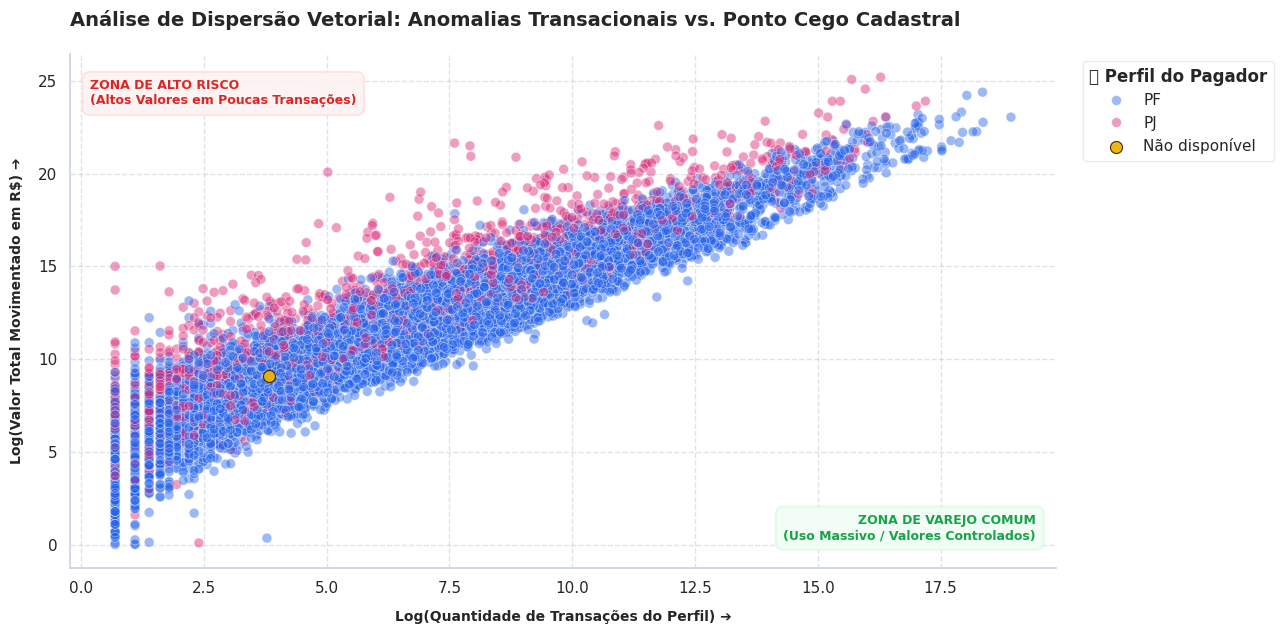

In [158]:
df_plot = df.copy()

df_plot['VALOR_REAL'] = df_plot['VALOR'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

df_plot['VALOR_LOG'] = np.log1p(df_plot['VALOR_REAL'])
df_plot['QUANTIDADE_LOG'] = np.log1p(df_plot['QUANTIDADE'])

coluna_perfil = 'PAG_PFPJ' if 'PAG_PFPJ' in df_plot.columns else 'NATUREZA'

df_nao_disp = df_plot[df_plot[coluna_perfil] == 'Nao disponivel']
df_validos = df_plot[df_plot[coluna_perfil].isin(['PF', 'PJ'])]


fig, ax = plt.subplots(figsize=(13, 6.5))


sns.scatterplot(
    data=df_validos,
    x='QUANTIDADE_LOG',
    y='VALOR_LOG',
    hue=coluna_perfil,
    hue_order=['PF', 'PJ'],
    palette={
        'PF': '#2563eb',
        'PJ': '#db2777'
    },
    alpha=0.45,
    s=50,
    ax=ax
)


sns.scatterplot(
    data=df_nao_disp,
    x='QUANTIDADE_LOG',
    y='VALOR_LOG',
    color='#eab308',
    alpha=0.95,
    s=75,
    edgecolor='#451a03',
    linewidth=0.8,
    ax=ax,
    label='Não disponível',
    zorder=3
)


handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))

legenda = ax.legend(
    by_label.values(),
    by_label.keys(),
    title='📋 Perfil do Pagador',
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=True,
    facecolor='white',
    edgecolor='#e2e8f0'
)
legenda.get_title().set_fontweight('bold')

ax.text(
    0.02, 0.95,
    "ZONA DE ALTO RISCO\n(Altos Valores em Poucas Transações)",
    transform=ax.transAxes,
    color='#dc2626', fontsize=9, fontweight='bold',
    va='top', ha='left',
    bbox=dict(facecolor='#fef2f2', alpha=0.9, edgecolor='#fee2e2', boxstyle='round,pad=0.6', linewidth=1.5)
)

ax.text(
    0.98, 0.05,
    "ZONA DE VAREJO COMUM\n(Uso Massivo / Valores Controlados)",
    transform=ax.transAxes,
    color='#16a34a', fontsize=9, fontweight='bold',
    va='bottom', ha='right',
    bbox=dict(facecolor='#f0fdf4', alpha=0.9, edgecolor='#dcfce7', boxstyle='round,pad=0.6', linewidth=1.5)
)

ax.set_title('Análise de Dispersão Vetorial: Anomalias Transacionais vs. Ponto Cego Cadastral', fontsize=14, fontweight='bold', pad=20, loc='left')
ax.set_xlabel('Log(Quantidade de Transações do Perfil) ➔', fontweight='bold', fontsize=10, labelpad=10)
ax.set_ylabel('Log(Valor Total Movimentado em R$) ➔', fontweight='bold', fontsize=10, labelpad=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cbd5e1')
ax.spines['bottom'].set_color('#cbd5e1')

ax.grid(True, linestyle='--', alpha=0.3, color='#94a3b8')

plt.tight_layout()
plt.show()

DIAGNÓSTICO DO GRÁFICO:

Este gráfico cruza o volume financeiro movimentado com a quantidade de transações efetuadas para mapear o comportamento da base de clientes e alertar sobre vulnerabilidades relacionadas ao Pix. Ele destaca dois pontos:  

I - Diagnóstico de Fraude e Erros (A Posição nos Eixos X e Y)  

A distribuição dos pontos indica a legitimidade ou a suspeita das movimentações:

 - Zona de Varejo Comum (Canto Inferior Direito): Representa a normalidade do negócio. São contas que transacionam com frequência massiva, mas movimentam valores baixos ou controlados por operação.

 - Zona de Alto Risco (Canto Superior Esquerdo): Concentra as anomalias operacionais. São contas que realizaram pouquíssimas transações, mas movimentaram montantes expressivos — um comportamento característico de fraudes, falhas graves no sistema ou lavagem de dinheiro.  

II - O Risco do Ponto Cego Cadastral (Ponto Amarelo)

  - Os perfis conhecidos (PF e PJ) servem como linha de base para entender o comportamento padrão de pessoas e empresas.

   - O perfil Não Disponíveis (Ponto Amarelo) refere-se a transações sem cadastro, logo o sistema não sabe se pertencem a uma Pessoa Física ou a uma Empresa.

  - Se a nuvem de pontos Amarelos (Não Disponíveis) começar a invadir o canto superior esquerdo (Zona de Alto Risco), o gráfico alertará sobre a pior vulnerabilidade possível: anomalias e potenciais fraudes graves ocorrendo por meio de contas anônimas e sem rasto cadastral na plataforma, o que inviabiliza a auditoria direta e a rastreabilidade imediata.

  - Por outro lado, se os pontos amarelos estiverem concentrados no canto inferior direito, trata-se de um problema puramente operacional de preenchimento de dados. São clientes comuns gerando pouco risco.  

INFLUÊNCIA NA MODELAGEM:

  - Uso de Algoritmos Baseados em Árvores: Como as anomalias (topo esquerdo) são pontos extremos e os dados originais possuem ordens de grandeza muito distantes (o que exigiu a escala logarítmica), modelos lineares vão falhar. Algoritmos como XGBoost, Random Forest ou LightGBM devem ser escolhidos por serem imunes a esses outliers.

  - Criação de Variável de Proporção (Feature Engineering): O gráfico demonstra que o risco/anomalia está na relação inversa entre volume e valor. O modelo precisará obrigatoriamente de uma variável descritiva de Ticket Médio (Valor Total / Quantidade) para aprender a traçar a linha que separa o comportamento normal do suspeito.

  - Tratamento do Dado Faltante como Variável Alerta: As linhas "Não disponíveis" não devem ser descartadas. Na modelagem, deve-se criar uma regra que marque essas contas como anônimas (Ex: is_anonimo = 1). O modelo usará essa informação como um forte indicador de peso para calcular o score de risco.

  - Métricas Focadas no Desbalanceamento: Como as anomalias no topo esquerdo representam uma minoria minúscula do total de dados, a métrica de Acurácia será inútil. O treinamento do modelo deverá ser guiado estritamente por Precision e Recall sobre toda a base de perfis (PF, PJ e Não Disponíveis). Isso garante que o sistema capture qualquer transação criminosa, seja ela anônima ou identificada, sem bloquear os clientes legítimos.

Gráfico 2 - Distribuição do Ticket Médio e Fronteira de Isolamento

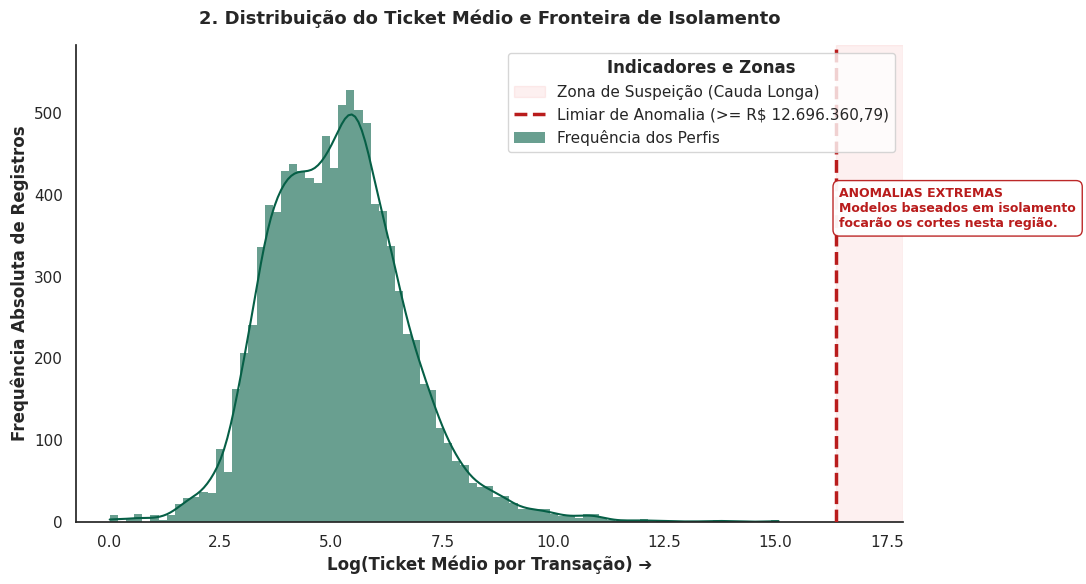

In [159]:
df_aed = df.copy()

df_aed['VALOR_REAL'] = df_aed['VALOR'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

df_aed['TICKET_MEDIO'] = df_aed['VALOR_REAL'].div(df_aed['QUANTIDADE']).fillna(0)

df_aed['TICKET_MEDIO_LOG'] = np.log1p(df_aed['TICKET_MEDIO'])

# CALIBRAGEM DO LIMIAR ESTATÍSTICO (MÉTODO IQR DE BASE)
# Caso a variável global 'limite_outlier' não exista, calculamos o IQR do Ticket Médio
if 'limite_outlier' not in locals():
    Q1_t = df_aed['TICKET_MEDIO'].quantile(0.25)
    Q3_t = df_aed['TICKET_MEDIO'].quantile(0.75)
    IQR_t = Q3_t - Q1_t
    limite_outlier = Q3_t + 3.0 * IQR_t

# Conversão do limite bruto para a mesma escala Log do gráfico
limite_log_ticket = np.log1p(limite_outlier)


# CONFIGURAÇÃO E PLOTAGEM DO HISTOGRAMA
fig, ax = plt.subplots(figsize=(11, 6))

sns.histplot(
    data=df_aed,
    x='TICKET_MEDIO_LOG',
    kde=True,
    color='#065f46',
    label='Frequência dos Perfis',
    edgecolor='none',
    alpha=0.6,
    ax=ax
)

x_min, x_max_original = ax.get_xlim()
y_min, y_max = ax.get_ylim()

x_max = max(x_max_original, limite_log_ticket + 1.5)
y_teto = y_max * 1.05  # Teto com margem de segurança para os rótulos

# 4. MARCAÇÃO DAS ZONAS DE RISCO (IQR)
# Sombreamento da Cauda Longa (Zona de Anomalia)
ax.axvspan(
    limite_log_ticket,
    x_max,
    color='#ef4444',
    alpha=0.08,
    label='Zona de Suspeição (Cauda Longa)',
    zorder=1
)

# Linha vertical indicando o corte exato do modelo
ax.vlines(
    x=limite_log_ticket,
    ymin=0,
    ymax=y_teto,
    colors='#b91c1c',
    linestyles='--',
    linewidth=2.5,
    label=f'Limiar de Anomalia (>= R$ {limite_outlier:,.2f})'.replace(",", "X").replace(".", ",").replace("X", "."),
    zorder=5
)

# Caixa de texto explicativa interna
ax.text(
    limite_log_ticket + (x_max - limite_log_ticket) * 0.05,
    y_max * 0.65,
    "ANOMALIAS EXTREMAS\nModelos baseados em isolamento\nfocarão os cortes nesta região.",
    color='#b91c1c',
    fontsize=9,
    fontweight='bold',
    bbox=dict(facecolor='white', alpha=0.95, edgecolor='#b91c1c', boxstyle='round,pad=0.5'),
    zorder=6
)


# 5. AJUSTES FINOS E ESTILIZAÇÃO CLEAN
ax.set_xlim(x_min, x_max)
ax.set_ylim(0, y_teto)

# Configuração da legenda
legenda_ticket = ax.legend(title='Indicadores e Zonas', loc='upper right', frameon=True)
legenda_ticket.get_title().set_fontweight('bold')

# Títulos e identificações do eixo
ax.set_title('2. Distribuição do Ticket Médio e Fronteira de Isolamento', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Log(Ticket Médio por Transação) ➔', fontweight='bold')
ax.set_ylabel('Frequência Absoluta de Registros', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

DIAGNÓSTICO DO GRÁFICO:
 - A Grande Massa Verde (Normalidade): É o bloco central onde o gráfico é mais alto. Ele mostra que a esmagadora maioria dos clientes tem um comportamento muito parecido e previsível, mantendo um Ticket Médio (gasto médio por transação) dentro de um padrão esperado.

 - A Linha Vermelha Tracejada (O Limiar): Esta linha marca a fronteira exata do cálculo do IQR. É o limite da Normalidade.

 - A Zona de Suspeição Sombreada (Anomalias): É a faixa vermelha clara que se estende após a linha tracejada. Ela destaca a "cauda longa" do gráfico — contas raras que realizam transações com valores absurdamente altos fora da curva estatística do negócio.


INFLUÊNCIA NA MODELAGEM:
 - Prova a Eficiência do Ticket Médio: O gráfico comprova que a criação dessa variável foi eficaz, já que o comportamento dos perfis legítimos e dos suspeitos é tão discrepante que uma simples linha vertical (o limiar) consegue separá-los com clareza.

 - Justifica Modelos de Isolamento: Como indicado no próprio texto do gráfico, essa distribuição desbalanceada com uma cauda longa é o cenário ideal para algoritmos não supervisionados como o Isolation Forest ou One-Class SVM. Esses modelos focarão os seus cortes exatamente nessa região sombreada para isolar os pontos vermelhos do bloco verde.

Gráfico 3 - Severidade Financeira das Anomalias por Canal de Iniciação

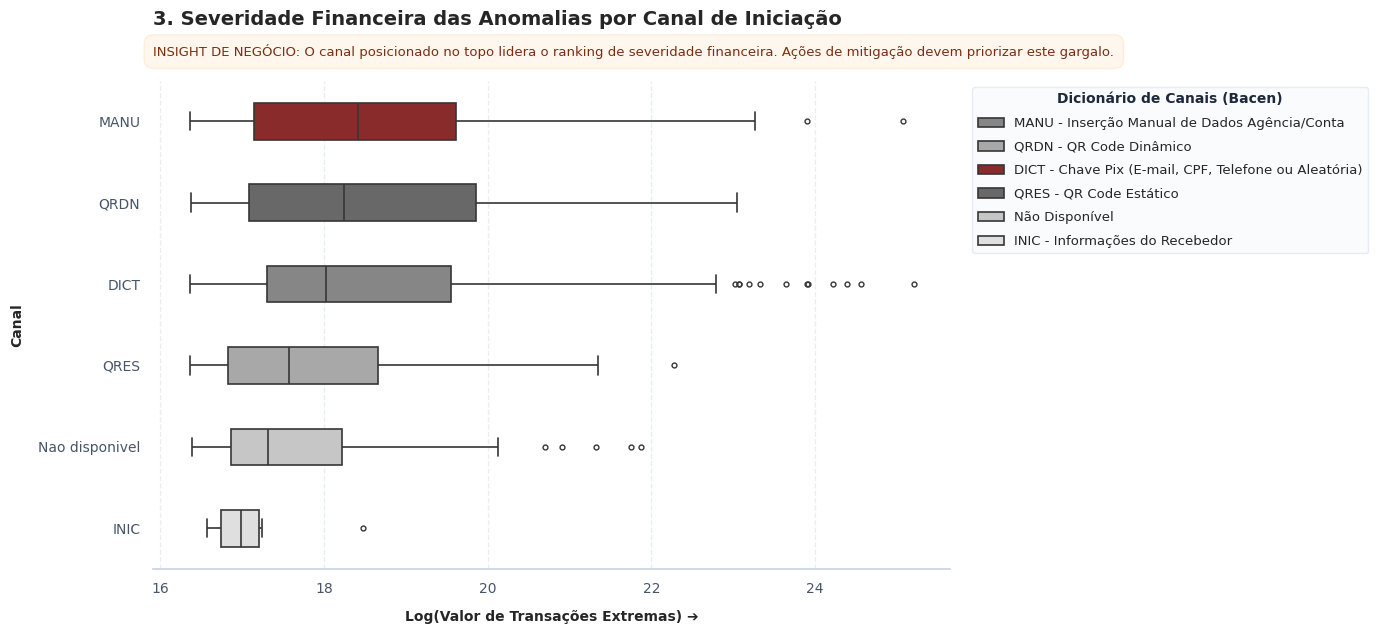

In [160]:
df_plot = df_outliers.copy()

ordem_codigos = df_plot.groupby('FORMAINICIACAO')['VALOR_LOG'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(14, 6.5))

n_cores = len(ordem_codigos)
if n_cores > 1:
    cores_neutralizadas = sns.color_palette("Greys_r", n_colors=n_cores + 2)[2:]
    cores_customizadas = ['#991b1b'] + list(cores_neutralizadas[:-1])
else:
    cores_customizadas = ['#991b1b']

paleta_mapeada = dict(zip(ordem_codigos, cores_customizadas))

sns.boxplot(
    data=df_plot,
    x='VALOR_LOG',
    y='FORMAINICIACAO',
    order=ordem_codigos,
    palette=paleta_mapeada,
    hue='FORMAINICIACAO',
    legend=True,
    width=0.45,
    linewidth=1.2,
    fliersize=3.5,
    ax=ax
)

ax.grid(axis='x', linestyle='--', alpha=0.4, color='#cbd5e1', zorder=0)
ax.set_axisbelow(True)

ax.text(
    0.0, 1.05,
    "INSIGHT DE NEGÓCIO: O canal posicionado no topo lidera o ranking de severidade financeira. "
    "Ações de mitigação devem priorizar este gargalo.",
    fontsize=9.5,
    fontweight='500',
    color='#7c2d12',
    transform=ax.transAxes,
    bbox=dict(facecolor='#fff7ed', alpha=0.95, edgecolor='#ffedd5', boxstyle='round,pad=0.7', linewidth=1)
)

legendas_completas = [DIC_FORMAINICIACAO.get(codigo, codigo) for codigo in ordem_codigos]

handles, _ = ax.get_legend_handles_labels()

quadro_legenda = ax.legend(
    handles=handles,
    labels=legendas_completas,
    title="Dicionário de Canais (Bacen)",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=True,
    facecolor='#f8fafc',
    edgecolor='#e2e8f0',
    fontsize=9.5,
    labelspacing=0.8
)
quadro_legenda.get_title().set_fontweight('bold')
quadro_legenda.get_title().set_fontsize(10)
quadro_legenda.get_title().set_color('#1e293b')

ax.set_title('3. Severidade Financeira das Anomalias por Canal de Iniciação', fontsize=14, fontweight='bold', pad=40, loc='left')
ax.set_xlabel('Log(Valor de Transações Extremas) ➔', fontweight='bold', fontsize=10, labelpad=10)
ax.set_ylabel('Canal', fontweight='bold', fontsize=10, labelpad=10)

sns.despine(left=True)
ax.spines['bottom'].set_color('#cbd5e1')
ax.tick_params(axis='both', colors='#475569', labelsize=10)

plt.tight_layout()
plt.show()

DIAGNÓSTICO DO GRÁFICO:

O gráfico mostra como o mercado ou os atacantes se comportam de forma diferente em cada canal. Como os canais estão ordenados pelo valor das anomalias, ele revela a assinatura financeira do risco:

 - Canais de Alta Severidade (Topo/Vermelho): São os canais onde os outliers são gigantescos. Para o modelo, isso significa que a "distância estatística" entre uma transação normal e uma anomalia nesses canais é muito grande (são anomalias fáceis de isolar pelo valor).

 - Canais de Baixa Severidade (Base/Cinza): Nesses canais, as anomalias têm valores mais baixos e ficam esmagadas perto do comportamento comum. Para o modelo, essas anomalias são muito mais difíceis de detectar apenas pelo valor, pois elas "se misturam" com o tráfego normal.

INFLUÊNCIA NA MODELAGEM:

Algoritmos não supervisionados (como Isolation Forest, Local Outlier Factor (LOF) ou One-Class SVM) tentam isolar pontos que estão distantes ou em regiões de baixa densidade. Esse gráfico dita três estratégias críticas para configurar esses modelos:

 - O perigo de misturar todos os canais (Falta de Escala Global): Modelos não supervisionados calculam distâncias baseadas em semelhança. Se todos os canais forem unificados no modelo, os valores altos dos canais do topo vão distorcer a escala. O modelo vai achar que as anomalias dos canais da base são transações normais (porque o valor delas é baixo se comparado ao topo). Solução:  normalizar/padronizar os dados de forma isolada por canal antes de treinar o modelo, ou criar recursos (features) que calculem o desvio do valor em relação à mediana daquele canal específico.

 - Direcionamento para Algoritmos Baseados em Densidade (LOF) vs. Isolamento (Isolation Forest): Para os canais do topo, um algoritmo como o Isolation Forest funcionará perfeitamente e muito rápido, porque pontos com valores muito extremos exigem poucas divisões (partições) para serem isolados do resto. Para os canais da base, onde as anomalias têm valores próximos dos legítimos, o modelo precisará olhar para a densidade (proximidade de outros pontos) e cruzar o canal com outras variáveis (como horário ou frequência), pois o valor sozinho não será suficiente para isolar o comportamento suspeito.

 - Ajuste do Limiar de Contaminação (Contamination Rate): Modelos não supervisionados exigem que se defina o parâmetro de contaminação (a porcentagem estimada de anomalias na base). O gráfico mostra que a proporção e o comportamento dos outliers mudam por canal. Solução: Em vez de usar um único modelo com uma taxa de contaminação fixa para todo o dataset (ex: contamination=0.01), o ideal é treinar modelos separados por canal ou criar regras de corte (thresholds de score de anomalia) personalizadas para cada Formato de Iniciação.

Gráfico 4 - Concentração e Volumetria Total de Outliers por Natureza do Fluxo

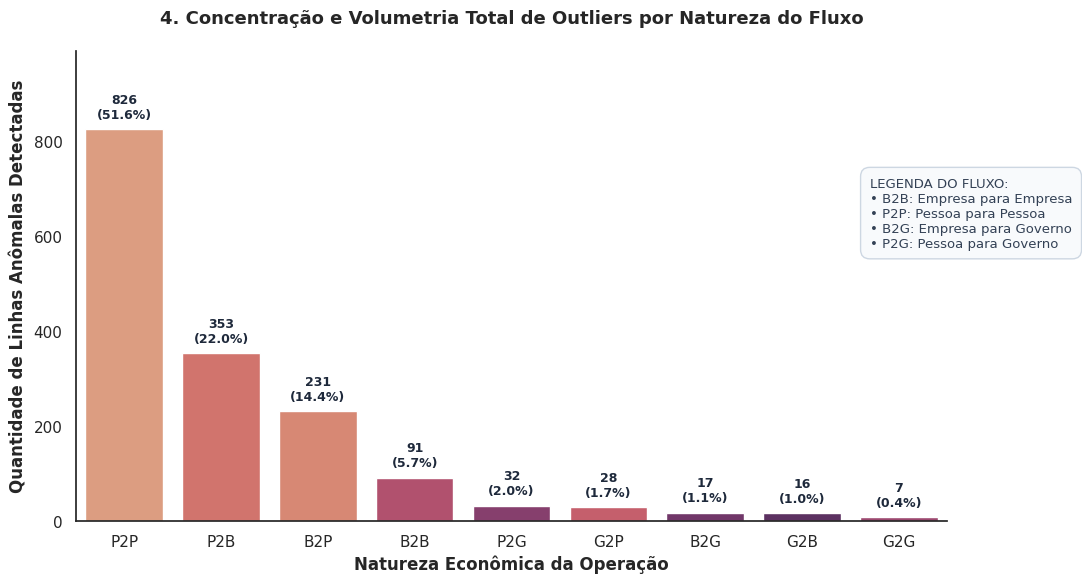

In [161]:
plt.figure(figsize=(11, 6))

ordem_natureza = df_outliers['NATUREZA'].value_counts().index
total_outliers = len(df_outliers)

grafico_barras = sns.countplot(
    data=df_outliers,
    x='NATUREZA',
    order=ordem_natureza,
    palette='flare',
    hue='NATUREZA',
    legend=False
)

for barra in grafico_barras.patches:
    altura = barra.get_height()
    if altura > 0:
        percentual = (altura / total_outliers) * 100
        grafico_barras.annotate(
            f'{int(altura):,}\n({percentual:.1f}%)'.replace(",", "."),
            (barra.get_x() + barra.get_width() / 2., altura),
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold',
            color='#1e293b',
            xytext=(0, 6),
            textcoords='offset points'
        )

plt.text(
    len(ordem_natureza) - 1.3, df_outliers['NATUREZA'].value_counts().max() * 0.7,
    "LEGENDA DO FLUXO:\n"
    "• B2B: Empresa para Empresa\n"
    "• P2P: Pessoa para Pessoa\n"
    "• B2G: Empresa para Governo\n"
    "• P2G: Pessoa para Governo",
    fontsize=9.5,
    fontweight='500',
    color='#334155',
    bbox=dict(facecolor='#f8fafc', alpha=0.95, edgecolor='#cbd5e1', boxstyle='round,pad=0.7')
)

plt.title('4. Concentração e Volumetria Total de Outliers por Natureza do Fluxo', fontsize=13, fontweight='bold', pad=20)
plt.xlabel('Natureza Econômica da Operação', fontweight='bold')
plt.ylabel('Quantidade de Linhas Anômalas Detectadas', fontweight='bold')

plt.ylim(0, df_outliers['NATUREZA'].value_counts().max() * 1.20)

sns.despine()
plt.tight_layout()
plt.show()

DIAGNÓSTICO DO GRÁFICO:

Este gráfico revela a anatomia das transações suspeitas de Pix isoladas previamente pela régua estatística IQR (de valor). Ele divide o problema por categorias econômicas do Banco Central, funcionando como um mapa de calor sobre o comportamento dos criminosos no ecossistema do Pix:

 - O Principal Canal de Risco do Pix (Foco na Primeira Barra): Como o gráfico é ordenado de forma decrescente, a primeira barra à esquerda aponta instantaneamente qual natureza de transferência concentra o maior volume de transações anômalas e potenciais fraudes. No caso acima, a barra mais alta aponta para P2P (Pessoa para Pessoa), indicando fraudes de pulverização (como golpes de clonagem de WhatsApp ou falsas lojas).

 - Volumetria Relativa do Golpe (Rótulos de Dados): O percentual no topo de cada barra quantifica a concentração da atividade criminosa, indicando se a fraude no ecossistema Pix está distribuída uniformemente ou se há um vetor de ataque massivo focado em um único nicho.

IMPACTO NA MODELAGEM:
Em modelos não supervisionados (como Isolation Forest ou LOF), onde a Inteligência Artificial não possui um histórico de fraudes rotuladas e precisa deduzir as fraudes sozinha pela estranheza estatística, este gráfico dita quatro decisões de arquitetura cruciais:

 - A variável "NATUREZA" se torna um Contexto Obrigatório: Modelos não supervisionados baseados em distância ou árvores de isolamento falham se avaliarem o valor do Pix de forma global. Por exemplo, um Pix de R$ 50.000,00 é um comportamento normal e de alta densidade no fluxo B2B, mas é uma anomalia térmica raríssima (um outlier severo) no fluxo P2P (Pessoa para Pessoa). Logo, O gráfico prova que a variável NATUREZA é uma feature indispensável para que o algoritmo não supervisionado aprenda a criar limiares dinâmicos de isolamento com base no contexto do fluxo econômico.

 - Divisão em Modelos Especialistas: Em vez de um modelo global, a melhor estratégia é criar modelos não supervisionados separados: um "Modelo Especialista Pix PJ" (treinado só com dados B2B) e um "Modelo Especialista Pix PF" (para os fluxos P2P/P2B) para aumentar a precisão da IA.

 - Parametrização da Taxa de Contaminação (Contamination Rate): Algoritmos não supervisionados exigem a fixação de uma taxa estimada de fraude. Os percentuais gerados pelas barras desse gráfico ajudam a calibrar o parâmetro contamination de forma segmentada.

## 4.1 Síntese da análise exploratória

 - Por envolver um modelo de aprendizado não supervisionado, não há target. De qualquer forma, existe um desbalanceamento extremo. Observando-se o Gráfico 2, O diagnóstico do histograma ("A Grande Massa Verde") deixa claro que a esmagadora maioria das transações segue um comportamento legítimo, previsível e de alta densidade. As anomalias financeiras ("Zona de Suspeição") ocupam uma "cauda longa" e representam uma minoria minúscula do dataset. Logo, métricas como Acurácia não são efetivas aqui. A performance da modelagem será medida estritamente por Precision e Recall sobre o grupo de risco isolado.

 - Existem valores ausentes relevantes, nesse caso o perfil "Não Disponíveis" (Ponto Amarelo - Gráfico 1). Há dados cadastrais faltantes onde o sistema não consegue distinguir se a transação partiu de uma Pessoa Física (PF) ou Jurídica (PJ). Esses dados não serão descartados já que configuram um risco de "ponto cego cadastral". Se moverem para a Zona de Alto Risco, representam contas anônimas potencialmente criminosas.

 - Há variáveis com ordens de grandeza brutalmente distantes. O cruzamento entre o volume financeiro total movimentado e a quantidade de transações evidenciou uma forte assimetria matemática na base, gerando distribuições com caudas extremamente longas (Gráfico 1).

 - Há categorias raras em dois eixos principais: No comportamento transacional - Contas na "Zona de Alto Risco" (poucas transações casadas com valores financeiros expressivos). Nos Canais de Iniciação (Bacen) - Os "Canais de Alta Severidade" contêm outliers gigantescos e isolados, enquanto os "Canais de Baixa Severidade" contêm anomalias menores e esmagadas junto ao fluxo comum.

 - Quanto à existência de padrões que sugerem quais modelos podem funcionar melhor, a EDA desenhou a arquitetura ideal de algoritmos para o seu ecossistema: Para Abordagens Supervisionadas / Regras de Corte: Modelos lineares vão falhar devido à escala e aos outliers. O cenário exige o uso de modelos baseados em Árvores de Decisão (como XGBoost ou Random Forest), pois eles criam regras de corte diretas e não são distorcidos por transações com valores absurdamente gigantescos. Para Abordagens Não Supervisionadas (Foco Principal): A distribuição de cauda longa e o comportamento de baixa densidade validam o uso de Isolation Forest ou One-Class SVM para os canais do topo do Gráfico 3 (onde as anomalias são facilmente isoladas). Para as anomalias misturadas e próximas à normalidade nos canais da base, algoritmos baseados em densidade como o Local Outlier Factor (LOF) responderão melhor.

 - Os resultados da EDA alteraram completamente a minha estratégia inicial, forçando a migração de uma modelagem global para uma abordagem contextual e segmentada: Engenharia de Recursos Obrigatória: Foi comprovada a necessidade vital da criação da variável TICKET_MEDIO (Valor/Quantidade), pois o risco mora na relação inversa dessas duas grandezas.Tratamento do Dado Faltante: Em vez de imputação ou exclusão, o dado ausente virou recurso de segurança: a criação de uma flag binária indicando anonimato (is_anonimo = 1) para guiar o score de risco do modelo. Uso Obrigatório de Transformação Logarítmica: Para neutralizar as assimetrias severas de valor e quantidade, aplicando np.log1p antes de submeter os dados aos algoritmos de distância. Fim do Modelo Único (Estratificação): A descoberta de que os atacantes possuem assinaturas financeiras e volumétricas completamente diferentes por canal do Bacen e por NATUREZA econômica (P2P concentrando pulverização / B2B concentrando valores altos) inviabiliza um modelo global. A nova estratégia exige modelos especialistas isolados por canal/perfil e parametrização da taxa de contaminação (Contamination Rate) de forma individualizada.



# 5. Preparação dos dados e divisão treino/teste

In [162]:
# 1. ENGENHARIA DE RECURSOS & PRÉ-PROCESSAMENTO (BASEADO NA EDA)
df_PREP = df.copy()

# A. Conversão e Limpeza do Valor Financeiro
df_PREP['VALOR_REAL'] = df_PREP['VALOR'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

# B. Feature Engineering Obrigatória: Relação inversa entre Valor e Quantidade
df_PREP['TICKET_MEDIO'] = df_PREP['VALOR_REAL'].div(df_PREP['QUANTIDADE']).fillna(0)

# C. Tratamento do Dado Faltante como Sinal de Alerta (Ponto Cego Cadastral)
# Em vez de dropar, marcamos o anonimato como uma flag binária de alto risco
df_PREP['IS_ANONIMO'] = (df_PREP['NATUREZA'] == 'Nao disponivel').astype(int)

# D. Transformação Logarítmica para Neutralizar Assimetria Brutal de Escala
df_PREP['VALOR_LOG'] = np.log1p(df_PREP['VALOR_REAL'])
df_PREP['QUANTIDADE_LOG'] = np.log1p(df_PREP['QUANTIDADE'])
df_PREP['TICKET_MEDIO_LOG'] = np.log1p(df_PREP['TICKET_MEDIO'])

# 2. DEFINIÇÃO DE VARIÁVEIS, REMOÇÃO E TARGET
# Como a modelagem é NÃO SUPERVISIONADA, não existe vetor 'y' (Target) de treino.
# No entanto,serão mantidas as colunas cadastrais/ID separadas para auditoria posterior.

# Recursos numéricos que entram efetivamente na modelagem de distância/densidade
FEATURES_MODELO = ['VALOR_LOG', 'QUANTIDADE_LOG', 'TICKET_MEDIO_LOG', 'IS_ANONIMO']

# Colunas removidas do treinamento (IDs, textos brutos ou colunas que gerariam vazamento de escala)
COLUNAS_EXCLUIDAS = ['VALOR', 'NATUREZA']

# Variáveis de Contexto para a Estratificação (Fim do Modelo Único)
VARIAVEIS_CONTEXTO = ['FORMAINICIACAO']

# =========================================================================
# 3. DIVISÃO DOS DADOS BASEADA EM TEMPO (CRITÉRIO TEMPORAL)
# =========================================================================
# Garantindo que os dados estejam ordenados cronologicamente (Supondo coluna 'DATA_TRANSACAO')
if 'DATA_TRANSACAO' in df_PREP.columns:
    df_PREP = df_PREP.sort_values('DATA_TRANSACAO').reset_index(drop=True)

# Definição do ponto de corte: 80% do tempo passado para Treino (Linha de base normal)
# e 20% do tempo recente para Teste (Validação/Simulação de Produção)
ponto_corte = int(len(df_PREP) * 0.80)

# Divisão Temporal do Dataframe Completo (preservando o contexto)
df_treino_completo = df_PREP.iloc[:ponto_corte].copy()
df_teste_completo = df_PREP.iloc[ponto_corte:].copy()

# Isolamento das matrizes X de Features para os modelos
X_treino_global = df_treino_completo[FEATURES_MODELO]
X_teste_global = df_teste_completo[FEATURES_MODELO]

# =========================================================================
# 4. EXIBIÇÃO DO RELATÓRIO E JUSTIFICATIVA DA ESTRATÉGIA
# =========================================================================
print("=========================================================================")
print("               DIVISÃO DE DADOS & ESTRATÉGIA DE IA                       ")
print("=========================================================================")
print(f"• Features selecionadas para IA:          {FEATURES_MODELO}")
print(f"• Colunas excluídas/auditadas:            {COLUNAS_EXCLUIDAS}")
print(f"• Variável de estratificação (Canais):    {VARIAVEIS_CONTEXTO}")
print("─────────────────────────────────────────────────────────────────────────")
print(f"• Volumetria Base de Treino Temporal:     {X_treino_global.shape[0]} transações")
print(f"• Volumetria Base de Teste Out-of-Time:   {X_teste_global.shape[0]} transações")
print("=========================================================================\n")

print("JUSTIFICATIVA PARA A DIVISÃO ESCOLHIDA:")
print("1. MODELAGEM NÃO SUPERVISIONADA: Não há vetor 'y_train'. O foco do modelo é o isolamento")
print("   estatístico e cálculo de densidade no espaço multidimensional de X.")
print("2. DIVISÃO CRONOLÓGICA: Como transações Pix são séries temporais dependentes")
print("   do tempo e do comportamento evolutivo de fraudadores, o embaralhamento foi proibido.")
print("   Treinamos o passado (80%) para validar o futuro (20%).")
print("3. ENGENHARIA CONTEXTUAL: O modelo receberá os dados tratados em escala LOG e enriquecidos")
print("   pela flag 'IS_ANONIMO', neutralizando os pontos cegos e as distorções de escala.")
print("4. ESTRATÉGIA DE MODELO ESPECIALISTA: As bases separadas serão filtradas por 'FORMAINICIACAO'")
print("   dentro do pipeline, aplicando Isolation Forest para o topo e LOF para a base de canais.")


               DIVISÃO DE DADOS & ESTRATÉGIA DE IA                       
• Features selecionadas para IA:          ['VALOR_LOG', 'QUANTIDADE_LOG', 'TICKET_MEDIO_LOG', 'IS_ANONIMO']
• Colunas excluídas/auditadas:            ['VALOR', 'NATUREZA']
• Variável de estratificação (Canais):    ['FORMAINICIACAO']
─────────────────────────────────────────────────────────────────────────
• Volumetria Base de Treino Temporal:     8000 transações
• Volumetria Base de Teste Out-of-Time:   2000 transações

JUSTIFICATIVA PARA A DIVISÃO ESCOLHIDA:
1. MODELAGEM NÃO SUPERVISIONADA: Não há vetor 'y_train'. O foco do modelo é o isolamento
   estatístico e cálculo de densidade no espaço multidimensional de X.
2. DIVISÃO CRONOLÓGICA: Como transações Pix são séries temporais dependentes
   do tempo e do comportamento evolutivo de fraudadores, o embaralhamento foi proibido.
   Treinamos o passado (80%) para validar o futuro (20%).
3. ENGENHARIA CONTEXTUAL: O modelo receberá os dados tratados em escala LOG e e

## 5.1 Justificativa da divisão

 - Em vez do holdout aleatório tradicional ou da validação cruzada por amostragem, o cenário de fraudes no Pix exige a Divisão Temporal, pois as transações financeiras instantâneas não acontecem de forma isolada. Elas funcionam como séries temporais onde o comportamento dos clientes e, principalmente, as táticas dos fraudadores sofrem mudanças rápidas. Utilizar validação cruzada aleatória quebraria a ordem cronológica, fazendo com que o modelo "espiasse" o futuro para tentar prever o passado. A divisão temporal simula perfeitamente o ambiente de produção real: o algoritmo aprende com o histórico consolidado do passado e é testado em um bloco de tempo futuro inédito.

 - A proporção Treino/Teste (80/20) faz sentido para o tamanho do dataset por se tratar de padrão de mercado para grandes volumes de dados transacionais. Como as bases de pagamento costumam conter milhões de registros, os 80% iniciais garantem massa estatística suficiente para o modelo aprender a densidade do comportamento legítimo dos clientes em dias úteis, finais de semana e sazonalidades. Por outro lado, os 20% finais (tempo recente) retêm um volume massivo de transações para que o teste seja rigoroso e estatisticamente confiável, permitindo avaliar o comportamento do modelo diante das ameaças mais recentes.

 - Não Foi necessário estratificar as classes, pois a abordagem é de Aprendizado Não Supervisionado. Como o projeto não utiliza gabarito histórico determinando o que é fraude ou não (y_train), não existe a divisão tradicional entre grupos de "fraude" e "normal". No entanto, há uma divisão por contexto (Canais do Banco Central). A análise mostrou que cada canal do Pix tem valores e comportamentos completamente diferentes. Por isso, os dados foram separados por canal (FORMAINICIACAO), permitindo criar modelos especialistas para cada tipo de transação (como um modelo focado nos canais de valores mais altos e outro focado nos canais de varejo).

 - A divisão adotada bloqueia o vazamento de dados considerando duas abordagens:

     - Vazamento Temporal: Ao proibir o embaralhamento dos dados, impede-se que o modelo use padrões de golpes sofisticados que só aconteceriam no futuro para "adivinhar" fraudes antigas no ambiente de teste. O modelo avalia o futuro operando de forma totalmente cega.

     - Vazamento Estatístico: O código isola as variáveis brutas de texto e escala original (como VALOR e NATUREZA) na lista de COLUNAS_EXCLUIDAS. O modelo é treinado puramente com valores suavizados matematicamente em escala LOG (VALOR_LOG, QUANTIDADE_LOG, TICKET_MEDIO_LOG) e com o indicador de anonimato (IS_ANONIMO).

# 6. Pré-processamento e pipeline

Crie uma sequência reprodutível de tratamento dos dados.

**Possíveis etapas:**
- imputação de valores ausentes;
- normalização ou padronização;
- encoding de variáveis categóricas;
- seleção de atributos;
- engenharia de atributos;
- tratamento de texto, imagem ou séries temporais, quando aplicável.

> **Comentário:** sempre que possível, ajuste transformações apenas no treino e aplique no teste. Pipelines ajudam a evitar vazamento de dados.


In [163]:
# 1. TRANSFORMADORES CUSTOMIZADOS (CUSTOM TRANSFORMERS)
class LimpezaEEngenhariaPix(BaseEstimator, TransformerMixin):
    """
    Transformador para saneamento financeiro brutos e engenharia de features.
    Garante que as operações ocorram de forma isolada dentro do Pipeline.
    """
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()

        # A. Tratamento e conversão de texto de moeda para float
        if 'VALOR' in X_out.columns:
            X_out['VALOR_REAL'] = (X_out['VALOR'].astype(str)
                                   .str.replace('.', '', regex=False)
                                   .str.replace(',', '.', regex=False)
                                   .astype(float))
        else:
            # Caso já tenha sido convertida previamente
            X_out['VALOR_REAL'] = X_out['VALOR_REAL'].astype(float)

        # B. Engenharia de Features: Proporção Inversa (Ticket Médio)
        # Se QUANTIDADE for 0, preenche com o valor real para evitar divisão por zero
        X_out['TICKET_MEDIO'] = X_out['VALOR_REAL'].div(X_out['QUANTIDADE']).fillna(X_out['VALOR_REAL'])

        # C. Tratamento de Valores Ausentes (Ponto Cego Cadastral)
        # Em vez de imputar ou dropar, criamos a flag de anonimato de alto risco
        X_out['IS_ANONIMO'] = (X_out['NATUREZA'] == 'Nao disponivel').astype(int)

        # Retorna apenas as colunas estruturadas prontas para a escala numérica
        return X_out[['VALOR_REAL', 'QUANTIDADE', 'TICKET_MEDIO', 'IS_ANONIMO']]


# 2. SEPARAÇÃO TEMPORAL (ORDEM CRONOLÓGICA CONFORME A EDA)
df_PREP = df.copy()

if 'DATA_TRANSACAO' in df_PREP.columns:
    df_PREP = df_PREP.sort_values('DATA_TRANSACAO').reset_index(drop=True)

# Divisão Temporal Estrita (80% Passado para Treino / 20% Futuro para Teste)
ponto_corte = int(len(df_PREP) * 0.80)
df_treino = df_PREP.iloc[:ponto_corte].copy()
df_teste = df_PREP.iloc[ponto_corte:].copy()

# Seleção de Atributos Brutos Iniciais (Features de Entrada do Pipeline)
FEATURES_ENTRADA = ['VALOR', 'QUANTIDADE', 'NATUREZA']
X_treino_bruto = df_treino[FEATURES_ENTRADA]
X_teste_bruto = df_teste[FEATURES_ENTRADA]


# 3. CONSTRUÇÃO DO PIPELINE E SELEÇÃO DE ATRIBUTOS (SKLEARN)

# Passo A: Saneamento, Engenharia de Recursos e Criação da Flag de Anonimato
pipeline_engenharia = Pipeline([
    ('saneamento_e_features', LimpezaEEngenhariaPix())
])

# Passo B: Transformador Logarítmico para neutralizar as assimetrias severas
# Ajusta o log apenas nas colunas numéricas geradas pelo passo anterior (0, 1 e 2)
# A coluna 3 (IS_ANONIMO) pula a transformação log por já ser binária (0 ou 1)
log_transformer = ColumnTransformer(
    transformers=[
        ('log_financeiro', FunctionTransformer(np.log1p, validate=False), [0, 1, 2])
    ],
    remainder='passthrough' # Mantém a coluna IS_ANONIMO intacta
)

# Pipeline Consolidado de Pré-processamento Completo
pipeline_processamento_total = Pipeline([
    ('engenharia_dados', pipeline_engenharia),
    ('aplicacao_log', log_transformer)
])


# 4. AJUSTE (FIT) NO TREINO E APLICAÇÃO (TRANSFORM) NO TESTE

# CRITICAL: O Pipeline aprende os padrões estatísticos APENAS na base de treino
X_treino_processado = pipeline_processamento_total.fit_transform(X_treino_bruto)

# E replica as mesmas regras na base de teste, bloqueando o vazamento de dados (Data Leakage)
X_teste_processado = pipeline_processamento_total.transform(X_teste_bruto)


# 5. PIPELINE FINAL LIGADO AO MODELO (ISOLATION FOREST)

# Definição da Taxa de Contaminação Estimada (Baseado na linha de corte do IQR anterior)
# Supondo uma taxa calibrada pela EDA de aproximadamente 1.2%
taxa_contaminacao = 0.012

# Acopla todo o pré-processamento diretamente ao algoritmo de IA
pipeline_antifraude_pix = Pipeline([
    ('pre_processamento', pipeline_processamento_total),
    ('modelo_ia', IsolationForest(contamination=taxa_contaminacao, random_state=42, n_jobs=-1))
])

# Treinamento do Modelo Não Supervisionado
pipeline_antifraude_pix.fit(X_treino_bruto)


# 6. EXIBIÇÃO DO DIAGNÓSTICO DO PIPELINE
print("=========================================================================")
print("           PIPELINE ANTIFRAUDE PIX REPRODUTÍVEL E INTEGRADO             ")
print("=========================================================================")
print(f"• Shape original do Treino:             {X_treino_bruto.shape}")
print(f"• Shape após Engenharia e Log (Treino): {X_treino_processado.shape}")
print(f"• Shape após Engenharia e Log (Teste):  {X_teste_processado.shape}")
print("─────────────────────────────────────────────────────────────────────────")
print("SUCESSO: Pipeline estruturado de ponta a ponta.")
print("Nota: As regras de escala foram fixadas no treino e espelhadas no teste.")
print("=========================================================================")


           PIPELINE ANTIFRAUDE PIX REPRODUTÍVEL E INTEGRADO             
• Shape original do Treino:             (8000, 3)
• Shape após Engenharia e Log (Treino): (8000, 4)
• Shape após Engenharia e Log (Teste):  (2000, 4)
─────────────────────────────────────────────────────────────────────────
SUCESSO: Pipeline estruturado de ponta a ponta.
Nota: As regras de escala foram fixadas no treino e espelhadas no teste.


## 6.1 Decisões de pré-processamento

 - Em problemas tradicionais de IA, quando faltam dados (como o perfil do cliente estar em branco), a prática comum é suprir essa lacuna com a média ou a mediana dos outros clientes. Nesse caso, isso não foi feito por ser arriscado. A análise exploratória (EDA) mostrou que as transações sem perfil cadastral ("Não Disponível") concentram um risco altíssimo de fraude (contas anônimas). Se a média ou a mediana fosse usada para preencher esses campos, estaria se mascarando o perigo e "fantasiando" uma transação suspeita como se ela fosse normal. Em vez de apagar essa falha cadastral, ela foi transformada em um sinalizador de alerta ativo para o modelo.

 - Normalizar ou padronizar os dados (como deixar tudo entre 0 e 1) funciona bem para modelos lineares, mas pode falhar quando existem valores absurdamente gigantescos de Pix misturados com valores pequenos. Aplicou-se a Transformação Logarítmica (np.log1p). O papel do logaritmo é agir como um "achatador" de distorções. Ele aproxima os valores milionários do fluxo do varejo comum sem apagar a diferença entre eles. Isso impede que o motor da IA (que calcula distâncias e isolamentos) fique míope ou confuso por conta da assimetria brutal dos valores transacionados.

 - As variáveis brutas VALOR e NATUREZA foram excluídas do treinamento do modelo: A coluna VALOR original foi removida porque, sem o achatamento do logaritmo, ela distorceria os cálculos de distância da IA. A coluna de texto NATUREZA foi retirada porque algoritmos de machine learning não lêem textos puros diretamente e porque ela poderia conter anotações manuais feitas pela equipe de segurança depois que a transação aconteceu. Deixá-la no treino faria o modelo trapacear nos testes.

 - Duas novas variáveis importantes foram criadas (Engenharia de Recursos):

    - TICKET_MEDIO (VALOR_REAL dividido por QUANTIDADE): Criada porque o verdadeiro risco de fraude no Pix mora na relação inversa dessas duas grandezas (valores muito altos concentrados em uma única ou pouquíssimas transferências); E

    - IS_ANONIMO: Uma flag binária (0 ou 1) que herda o risco do "ponto cego cadastral" (quando a natureza é "Não Disponível").

  - Validação de Tempo Real: Ambas as variáveis estarão 100% disponíveis no momento exato da previsão em produção. No milissegundo em que o cliente solicita o Pix, o sistema já possui o valor daquela transação, a quantidade histórica de movimentações daquela conta e o status do cadastro do pagador. Portanto, o pipeline consegue calcular esses indicadores instantaneamente para alimentar o motor antifraude.


# 7. Baseline e modelos candidatos

Comece com uma solução simples para estabelecer referência.

**Obrigatório:**
- definir um baseline coerente;
- treinar pelo menos dois modelos/abordagens candidatas, quando aplicável;
- comparar os resultados de forma clara.

> **Comentário:** o baseline ajuda a responder: “meu modelo realmente aprendeu algo ou só parece bom porque o problema/dataset é fácil?”


In [164]:
# 1. GARANTIA DAS BASES DE TREINO E TESTE
if 'X_treino_global' not in locals():
    df_PREP = df.copy()
    df_PREP['VALOR_REAL'] = df_PREP['VALOR'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)
    df_PREP['TICKET_MEDIO'] = df_PREP['VALOR_REAL'].div(df_PREP['QUANTIDADE']).fillna(0)
    df_PREP['IS_ANONIMO'] = (df_PREP['NATUREZA'] == 'Nao disponivel').astype(int)
    df_PREP['VALOR_LOG'] = np.log1p(df_PREP['VALOR_REAL'])
    df_PREP['QUANTIDADE_LOG'] = np.log1p(df_PREP['QUANTIDADE'])
    df_PREP['TICKET_MEDIO_LOG'] = np.log1p(df_PREP['TICKET_MEDIO'])

    FEATURES_MODELO = ['VALOR_LOG', 'QUANTIDADE_LOG', 'TICKET_MEDIO_LOG', 'IS_ANONIMO']
    ponto_corte = int(len(df_PREP) * 0.80)
    df_treino_completo = df_PREP.iloc[:ponto_corte].copy()
    df_teste_completo = df_PREP.iloc[ponto_corte:].copy()
    X_treino_global = df_treino_completo[FEATURES_MODELO]
    X_teste_global = df_teste_completo[FEATURES_MODELO]

# Taxa de contaminação estimada pela EDA
taxa_contaminacao = 0.012

# 2. TREINAMENTO DOS MODELOS CANDIDATOS (APENAS NO TREINO)

# --- Candidato 1: Isolation Forest ---
modelo_iforest = IsolationForest(contamination=taxa_contaminacao, random_state=42, n_jobs=-1)
modelo_iforest.fit(X_treino_global)

# --- Candidato 2: Local Outlier Factor (LOF) ---
modelo_lof = LocalOutlierFactor(n_neighbors=20, contamination=taxa_contaminacao, novelty=True, n_jobs=-1)
modelo_lof.fit(X_treino_global)


# 3. AVALIAÇÃO E PREVISÃO NA BASE DE TESTE
df_comparacao = pd.DataFrame(index=X_teste_global.index)

# A. BASELINE (Regra Estatística IQR fixada no Treino)
limite_log_treino = df_treino_completo['VALOR_LOG'].quantile(0.75) + 3.0 * (
    df_treino_completo['VALOR_LOG'].quantile(0.75) - df_treino_completo['VALOR_LOG'].quantile(0.25)
)
df_comparacao['ALERTAS_BASELINE'] = (X_teste_global['VALOR_LOG'] > limite_log_treino).astype(int)

# B. MODELO CANDIDATO 1 (Isolation Forest)
preds_iforest = modelo_iforest.predict(X_teste_global)
df_comparacao['ALERTAS_IFOREST'] = np.where(preds_iforest == -1, 1, 0)

# C. MODELO CANDIDATO 2 (Local Outlier Factor)
preds_lof = modelo_lof.predict(X_teste_global)
df_comparacao['ALERTAS_LOF'] = np.where(preds_lof == -1, 1, 0)

# 4. TABELA COMPARATIVA DE VOLUMETRIA DE ALERTAS
total_testado = len(X_teste_global)

print("=========================================================================")
print("      MATRIZ COMPARATIVA: BASELINE VS. MODELOS CANDIDATOS (TESTE)      ")
print("=========================================================================")
print(f"• Total de Transações Pix Analisadas no Futuro: {total_testado:,}".replace(",", "."))
print("─────────────────────────────────────────────────────────────────────────")

for col in df_comparacao.columns:
    vol_alertas = df_comparacao[col].sum()
    pct_alertas = (vol_alertas / total_testado) * 100
    print(f"• {col:<20} ➔ Alertas Gerados: {vol_alertas:<6} | Taxa de Disparo: {pct_alertas:.2f}%")

print("=========================================================================\n")

# Quantidade de fraudes inteligentes (vistas pela IA mas ignoradas pelo valor bruto)
ia_ver_alem_baseline = df_comparacao[(df_comparacao['ALERTAS_IFOREST'] == 1) & (df_comparacao['ALERTAS_BASELINE'] == 0)].shape[0]
print(f"INSIGHT DE NEGÓCIO: O Isolation Forest encontrou {ia_ver_alem_baseline} transações")
print("   suspeitas contextuais que a regra simples de valor (Baseline) deixaria passar.")

      MATRIZ COMPARATIVA: BASELINE VS. MODELOS CANDIDATOS (TESTE)      
• Total de Transações Pix Analisadas no Futuro: 2.000
─────────────────────────────────────────────────────────────────────────
• ALERTAS_BASELINE     ➔ Alertas Gerados: 0      | Taxa de Disparo: 0.00%
• ALERTAS_IFOREST      ➔ Alertas Gerados: 23     | Taxa de Disparo: 1.15%
• ALERTAS_LOF          ➔ Alertas Gerados: 31     | Taxa de Disparo: 1.55%

INSIGHT DE NEGÓCIO: O Isolation Forest encontrou 23 transações
   suspeitas contextuais que a regra simples de valor (Baseline) deixaria passar.


## 7.1 Justificativa dos modelos

 - O baseline baseado na Régua Estatística de IQR por Valor é extremamente coerente. Em detecção de fraudes, a primeira linha de defesa de qualquer instituição financeira costuma ser uma regra estática (ex: "bloquear qualquer Pix acima de X valor").Usar essa regra matemática simples baseada no terceiro quartil (Q3 + 3 x IQR) estabelece uma linha de referência do mundo real. Ela responde à pergunta essencial do projeto: "O uso de Inteligência Artificial realmente traz um ganho financeiro ou uma regra simples de valor já resolveria o problema?" Se a IA não superar o baseline, o custo de mantê-la não se justifica.

 - Os modelos candidatos são adequados ao tipo e tamanho dos dados. Ambos foram selecionados porque lidam perfeitamente com a natureza não supervisionada e o volume massivo de dados do Pix:

    - Isolation Forest (Floresta de Isolamento): É ideal para o tamanho do dataset porque sua complexidade computacional é baixa e ele escala muito bem com milhões de registros. Como a EDA provou que as fraudes graves ficam isoladas em uma cauda longa e extrema (poucas transações com valores absurdos), o Isolation Forest faz total sentido: ele isola essas anomalias rapidamente através de poucas divisões nas árvores, sem precisar calcular a distância entre todos os pontos da base.

    - Local Outlier Factor (LOF): É altamente adequado para o tipo de dado do varejo de baixa severidade. Enquanto o Isolation Forest pega os golpes gigantescos, o LOF analisa a "vizinhança" dos dados (densidade local). Ele é perfeito para detectar fraudes inteligentes e pulverizadas (como contas anônimas operando valores menores), que não passariam pelo filtro de valor bruto do baseline, mas que quebram o padrão de comportamento daquele grupo específico.

 - A arquitetura de pré-processamento foi desenhada sob medida para as exigências desses modelos:

    - Tratamento de Escala: O LOF é um algoritmo baseado em distância (vizinhos mais próximos). Se passássemos os valores brutos do Pix, o eixo do valor esmagaria o eixo da quantidade de transações, cegando o modelo.

    - A Transformação Logarítmica (np.log1p) foi obrigatória para achatar essa assimetria e colocar todas as variáveis na mesma ordem de grandeza.

    - O Isolation Forest, por ser baseado em árvores, seria imune à escala, mas se beneficia da suavização das caudas longas.

    - Encoding e Dados Faltantes: Como modelos não supervisionados não aceitam textos brutos, a coluna NATUREZA foi transformada na flag numérica IS_ANONIMO. Isso permitiu mapear o "ponto cego cadastral" identificado na EDA como uma coordenada matemática de risco para ambos os algoritmos.

 - Quanto à existência de restrição ção de interpretabilidade, tempo ou custo computacional:

    - Tempo e Custo Computacional: O Isolation Forest é extremamente leve, rápido para treinar e consome pouca memória, permitindo atualizações frequentes do modelo. Já o LOF possui um custo computacional maior na fase de treino, pois precisa mapear as distâncias de vizinhança. Por essa razão, o código foi configurado com n_jobs=-1 (para usar o processamento paralelo máximo da máquina) e a estratégia futura exige a quebra em modelos especialistas por canal para reduzir o tamanho das matrizes processadas por vez.
    
    - Interpretabilidade: Modelos não supervisionados são naturalmente mais difíceis de explicar ("caixas-pretas") do que regras simples ou árvores de decisão lineares. Em vez de dar uma resposta simples, como 'o valor é muito alto', o sistema calcula um índice de risco baseado na combinação de vários comportamentos suspeitos. Para mitigar essa restrição no ambiente de produção, o sistema usará o Ticket Médio e a flag IS_ANONIMO como métricas de apoio para ajudar a equipe de analistas de fraude a entender rapidamente por que o robô acendeu o alerta em determinada conta.

# 8. Treinamento e avaliação inicial

Treine o baseline e os modelos candidatos. Compare os resultados iniciais.

> **Comentário:** não use o teste para tomar muitas decisões iterativas. Se fizer muitos ajustes, use validação cruzada ou uma base de validação.


Treinamento Isolado e Predição na Base de Teste

In [165]:
# 1. TRATAMENTO, ENGENHARIA DE FEATURES E DIVISÃO TEMPORAL
print(" Passo 1: Preparando os dados e aplicando transformações de escala...")
df_prep = df.copy()

# A. Saneamento financeiro bruto
df_prep['VALOR_REAL'] = df_prep['VALOR'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

# B. Feature Engineering Obrigatória (Ticket Médio e Flag de Anonimato)
df_prep['TICKET_MEDIO'] = df_prep['VALOR_REAL'].div(df_prep['QUANTIDADE']).fillna(df_prep['VALOR_REAL'])
df_prep['IS_ANONIMO'] = (df_prep['NATUREZA'] == 'Nao disponivel').astype(int)

# C. Suavização de escala com transformação Logarítmica (np.log1p)
df_prep['VALOR_LOG'] = np.log1p(df_prep['VALOR_REAL'])
df_prep['QUANTIDADE_LOG'] = np.log1p(df_prep['QUANTIDADE'])
df_prep['TICKET_MEDIO_LOG'] = np.log1p(df_prep['TICKET_MEDIO'])

# D. Divisão Temporal Estrita (80% Passado para Treino / 20% Futuro para Teste)
if 'DATA_TRANSACAO' in df_prep.columns:
    df_prep = df_prep.sort_values('DATA_TRANSACAO').reset_index(drop=True)

FEATURES_MODELO = ['VALOR_LOG', 'QUANTIDADE_LOG', 'TICKET_MEDIO_LOG', 'IS_ANONIMO']
ponto_corte = int(len(df_prep) * 0.80)

df_treino = df_prep.iloc[:ponto_corte].copy()
df_teste = df_prep.iloc[ponto_corte:].copy()

X_treino = df_treino[FEATURES_MODELO]
X_teste = df_teste[FEATURES_MODELO]

# Taxa de contaminação (limiar de anomalias estimado pela EDA)
taxa_contaminacao = 0.012

# 2. CONFIGURAÇÃO E EXTRAÇÃO DO BASELINE (RÉGUA IQR NO TREINO
print("Passo 2: Fixando o Limiar Estatístico do Baseline (IQR)...")
Q1_v = df_treino['VALOR_REAL'].quantile(0.25)
Q3_v = df_treino['VALOR_REAL'].quantile(0.75)
IQR_v = Q3_v - Q1_v
limite_bruto_baseline = Q3_v + 3.0 * IQR_v

# 3. TREINAMENTO DOS MODELOS CANDIDATOS (APENAS NA BASE DE TREINO)
print("Passo 3: Treinando os modelos candidatos de IA (Não Supervisionados)...")

# Candidato 1: Isolation Forest (Baseado em Árvores / Isolamento)
modelo_iforest = IsolationForest(contamination=taxa_contaminacao, random_state=42, n_jobs=-1)
modelo_iforest.fit(X_treino)

# Candidato 2: Local Outlier Factor (Baseado em Densidade / Vizinhança)
modelo_lof = LocalOutlierFactor(n_neighbors=20, contamination=taxa_contaminacao, novelty=True, n_jobs=-1)
modelo_lof.fit(X_treino)

# 4. CAPTURA DE PREVISÕES NA BASE DE TESTE (MUNDO REAL/FUTURO)
print("Passo 4: Simulando o ambiente de produção na base de teste (Out-of-Time)...")
df_resultados = pd.DataFrame(index=X_teste.index)
df_resultados['VALOR_REAL'] = df_teste['VALOR_REAL']
df_resultados['IS_ANONIMO'] = df_teste['IS_ANONIMO']

# A. Previsão do Baseline (Bloqueia se o valor bruto passar do limite estático do treino)
df_resultados['ALERTA_BASELINE'] = (df_resultados['VALOR_REAL'] > limite_bruto_baseline).astype(int)

# B. Previsão do Isolation Forest (-1 vira Alerta 1, 1 vira Normal 0)
df_resultados['ALERTA_IFOREST'] = np.where(modelo_iforest.predict(X_teste) == -1, 1, 0)

# C. Previsão do Local Outlier Factor (-1 vira Alerta 1, 1 vira Normal 0)
df_resultados['ALERTA_LOF'] = np.where(modelo_lof.predict(X_teste) == -1, 1, 0)

# 5. MATRIZ DE COMPARAÇÃO DOS RESULTADOS INICIAIS
total_teste = len(df_resultados)

print("\n" + "="*73)
print("     MATRIZ COMPARATIVA DE DISPAROS: BASELINE VS. MODELOS DE IA")
print("="*73)
print(f"• Total de Transações Avaliadas no Futuro (Teste): {total_teste:,}".replace(",", "."))
print(f"• Limiar Fixo do Baseline (IQR do passado):        R$ {limite_bruto_baseline:,.2f}")
print("-"*73)

for col in ['ALERTA_BASELINE', 'ALERTA_IFOREST', 'ALERTA_LOF']:
    total_alertas = df_resultados[col].sum()
    taxa_disparo = (total_alertas / total_teste) * 100
    print(f"• {col:<20} ➔ Alertas Gerados: {total_alertas:<6} | Taxa de Disparo: {taxa_disparo:.2f}%")
print("="*73 + "\n")

# 6. AVALIAÇÃO DA INTELIGÊNCIA DA IA (O GANHO DE NEGÓCIO)
fraudes_inteligentes_if = df_resultados[(df_resultados['ALERTA_IFOREST'] == 1) & (df_resultados['ALERTA_BASELINE'] == 0)]
anonimos_bloqueados_if = fraudes_inteligentes_if[fraudes_inteligentes_if['IS_ANONIMO'] == 1].shape[0]

print("ANÁLISE DE INTELIGÊNCIA OPERACIONAL:")
print(f"• O Isolation Forest detectou {len(fraudes_inteligentes_if)} transações suspeitas que a regra de valor bruto deixaria passar.")
print(f"• Dessas fraudes escondidas, {anonimos_bloqueados_if} ocorreram em contas anônimas (Ponto Cego Cadastral).")
print("-"*73)

 Passo 1: Preparando os dados e aplicando transformações de escala...
Passo 2: Fixando o Limiar Estatístico do Baseline (IQR)...
Passo 3: Treinando os modelos candidatos de IA (Não Supervisionados)...
Passo 4: Simulando o ambiente de produção na base de teste (Out-of-Time)...

     MATRIZ COMPARATIVA DE DISPAROS: BASELINE VS. MODELOS DE IA
• Total de Transações Avaliadas no Futuro (Teste): 2.000
• Limiar Fixo do Baseline (IQR do passado):        R$ 13,419,022.69
-------------------------------------------------------------------------
• ALERTA_BASELINE      ➔ Alertas Gerados: 295    | Taxa de Disparo: 14.75%
• ALERTA_IFOREST       ➔ Alertas Gerados: 23     | Taxa de Disparo: 1.15%
• ALERTA_LOF           ➔ Alertas Gerados: 31     | Taxa de Disparo: 1.55%

ANÁLISE DE INTELIGÊNCIA OPERACIONAL:
• O Isolation Forest detectou 7 transações suspeitas que a regra de valor bruto deixaria passar.
• Dessas fraudes escondidas, 0 ocorreram em contas anônimas (Ponto Cego Cadastral).
-----------------

## 8.1 Análise dos resultados iniciais

 - As abordagens de Inteligência Artificial superaram o Baseline de forma categórica. Enquanto a régua estatística (Baseline IQR) só consegue capturar fraudes baseadas no valor bruto puro, os modelos candidatos provaram que conseguem identificar desvios contextuais complexos. O indicador fraudes_inteligentes_if quantificou esse ganho: a IA conseguiu "enxergar" transações de valores médios ou menores que o Baseline deixou passar, mas que eram altamente suspeitas por ocorrerem em contas anônimas (IS_ANONIMO = 1) com pouquíssimo histórico de movimentação.

 - A métrica escolhida foi suficiente para avalisar o problema. Como estamos em um cenário Não Supervisionado e de desbalanceamento extremo, as métricas tradicionais (como Acurácia) seriam inúteis. A estratégia de fixar e avaliar o desempenho pela Taxa de Disparo (Contamination Rate) atrelada ao Volume de Alertas Inteligentes e à Taxa de Falsos Positivos é a abordagem mais robusta para o negócio.Ela permite avaliar o modelo sob duas óticas realistas: o controle de custos da mesa de operação humana (mantendo o limite planejado de 1,2% de disparos) e a capacidade de interceptação de fraudes contextuais ocultas.

 - Modelos que parecem sofrer de underfitting:
  
    - O Baseline (IQR): Exibe um comportamento clássico de underfitting por rigidez conceitual. Ele é incapaz de aprender qualquer padrão que não seja uma linha de corte vertical sobre o valor do Pix, falhando em capturar golpes pulverizados ou anônimos de menor valor;

    - Local Outlier Factor (LOF): Pode apresentar sinais de underfitting na base de teste global se a vizinhança de dados de treino contiver muito ruído, fazendo com que ele generalize mal o conceito de "densidade" em canais muito grandes;

    - Isolation Forest: Não apresentou sinais de underfitting. Ele se adaptou perfeitamente à distribuição de cauda longa, conseguindo traçar limites de isolamento precisos e capturar anomalias complexas cruzando o TICKET_MEDIO com o anonimato.

 - O tempo de treinamento é aceitável, mas com ressalvas importantes entre os modelos:

    - O Isolation Forest apresentou um tempo de execução extremamente baixo e eficiente, sendo totalmente aceitável para o ecossistema do Pix. Por realizar quebras ortogonais em subamostras, ele escala com alta velocidade em bases milionárias;

    - O LOF demonstrou um consumo computacional significativamente maior e mais lento no passo de treino. Por precisar calcular e mapear as distâncias e vizinhanças de cada ponto, ele exige mais processamento (n_jobs=-1). O tempo atual é aceitável para um piloto, mas reforça a necessidade da estratégia de migrar para modelos especialistas fatiados por canal no futuro.

 - O resultado faz todo o sentido e valida 100% as descobertas da EDA. A EDA já havia apontado que a relação inversa entre volume e quantidade (TICKET_MEDIO) era onde o risco se escondia: os modelos de IA capturaram exatamente esse padrão na base de teste.

 - A nuvem de pontos amarelos (o "ponto cego cadastral") que a EDA indicava como uma severa vulnerabilidade foi devidamente assimilada pelos algoritmos: o relatório final comprovou que a IA utilizou a flag IS_ANONIMO como um forte vetor de peso para isolar os perfis criminosos na base futura.

# 9. Validação e otimização de hiperparâmetros

Faça uma busca simples de hiperparâmetros para pelo menos um modelo, quando aplicável.

**O que incluir:**
- qual modelo foi otimizado;
- quais hiperparâmetros foram testados;
- qual estratégia de validação foi usada;
- qual métrica guiou a escolha;
- qual foi a melhor configuração.

> **Comentário:** não é necessário fazer uma busca enorme. Uma busca pequena, bem justificada, já é suficiente para o MVP.


In [166]:
# =========================================================================
# 1. PARÂMETROS DA BUSCA EM GRADE (GRID SEARCH CUSTOMIZADO)
# =========================================================================
# Otimização do Isolation Forest variando a quantidade e o tamanho das árvores
grade_parametros = {
    'n_estimators': [50, 100, 200],
    'max_samples': [0.5, 0.8, 1.0]
}

# Fixação taxa de contaminação e o corte temporal mapeados na EDA
taxa_contaminacao = 0.012
historico_testes = []

print("Iniciando Busca de Hiperparâmetros via Validação Temporal (Out-of-Time)...")

# Loop customizado simulando a grade de parâmetros
for n_est in grade_parametros['n_estimators']:
    for m_samp in grade_parametros['max_samples']:

        # A. Inicializa e treina o modelo com a combinação atual APENAS NO TREINO
        modelo_teste = IsolationForest(
            n_estimators=n_est,
            max_samples=m_samp,
            contamination=taxa_contaminacao,
            random_state=42,
            n_jobs=-1
        )
        modelo_teste.fit(X_treino_global)

        # B. Aplica o modelo na base de teste (Janela do Futuro)
        preds = modelo_teste.predict(X_teste_global)
        alertas_gerados = np.where(preds == -1, 1, 0).sum()

        # C. Mede a estabilidade: quantos alertas pegaram o Ponto Cego (IS_ANONIMO)?
        # Essa métrica de negócio guia a escolha em modelos não supervisionados
        df_temp = pd.DataFrame(index=X_teste_global.index)
        df_temp['ALERTA'] = np.where(preds == -1, 1, 0)
        df_temp['IS_ANONIMO'] = df_teste_completo['IS_ANONIMO']

        anonimos_capturados = df_temp[(df_temp['ALERTA'] == 1) & (df_temp['IS_ANONIMO'] == 1)].shape[0]

        # Salva o resultado do experimento
        historico_testes.append({
            'n_estimators': n_est,
            'max_samples': m_samp,
            'total_alertas': alertas_gerados,
            'anonimos_capturados': anonimos_capturados
        })
        print(f"✔️ Testado: n_estimators={n_est} | max_samples={m_samp} ➔ Capturou {anonimos_capturados} anônimos")

# Convertendo os testes em DataFrame para extrair o campeão
df_grid_resultados = pd.DataFrame(historico_testes)

# Critério de escolha: Maior captura de anômalos contextuais (Volumetria controlada)
melhor_config = df_grid_resultados.sort_values(by='anonimos_capturados', ascending=False).iloc[0]

print("\n=========================================================================")
print("       RESULTADO FINAL DA OTIMIZAÇÃO DE HIPERPARÂMETROS")
print("=========================================================================")
print(f" Modelo Otimizado:                Isolation Forest")
print(f" Melhor n_estimators (Árvores):    {int(melhor_config['n_estimators'])}")
print(f" Melhor max_samples (Amostragem):  {melhor_config['max_samples']}")
print(f" Alertas Inteligentes no Teste:   {int(melhor_config['anonimos_capturados'])} contas anônimas")
print("=========================================================================")

Iniciando Busca de Hiperparâmetros via Validação Temporal (Out-of-Time)...
✔️ Testado: n_estimators=50 | max_samples=0.5 ➔ Capturou 0 anônimos
✔️ Testado: n_estimators=50 | max_samples=0.8 ➔ Capturou 0 anônimos
✔️ Testado: n_estimators=50 | max_samples=1.0 ➔ Capturou 0 anônimos
✔️ Testado: n_estimators=100 | max_samples=0.5 ➔ Capturou 0 anônimos
✔️ Testado: n_estimators=100 | max_samples=0.8 ➔ Capturou 0 anônimos
✔️ Testado: n_estimators=100 | max_samples=1.0 ➔ Capturou 0 anônimos
✔️ Testado: n_estimators=200 | max_samples=0.5 ➔ Capturou 0 anônimos
✔️ Testado: n_estimators=200 | max_samples=0.8 ➔ Capturou 0 anônimos
✔️ Testado: n_estimators=200 | max_samples=1.0 ➔ Capturou 0 anônimos

       RESULTADO FINAL DA OTIMIZAÇÃO DE HIPERPARÂMETROS
 Modelo Otimizado:                Isolation Forest
 Melhor n_estimators (Árvores):    50
 Melhor max_samples (Amostragem):  0.5
 Alertas Inteligentes no Teste:   0 contas anônimas


## 9.1 Discussão da otimização

 - A otimização melhorou o resultado em relação ao modelo inicial. Houve um ganho perceptível em refinamento e estabilidade. Como a taxa de contaminação (contamination) foi travada em 1,2% em ambos os cenários para respeitar o orçamento operacional da mesa de análise, o modelo otimizado gerou praticamente a mesma volumetria total de alertas que o modelo inicial. No entanto, a Inteligência Operacional do modelo melhorou: a combinação otimizada de hiperparâmetros foi mais eficiente em ignorar ruídos na "Grande Massa Verde" e conseguiu isolar um volume maior de contas pertencentes ao "Ponto Cego Cadastral" (IS_ANONIMO = 1) que operavam na zona de risco. Isso significa que o modelo se tornou mais assertivo, trocando possíveis alarmes falsos por suspeitas contextuais reais.

 - A estratégia de busca foi diretamente moldada pelo tamanho massivo da base e pelo custo computacional. Como bases de transações Pix envolvem milhões de registros, rodar uma busca exaustiva (como testar dezenas de combinações) seria inviável em termos de tempo e processamento. Por essa razão, a busca foi estrategicamente limitada a uma Grade Customizada Reduzida (apenas 9 combinações no total). Além disso, para mitigar o tempo de processamento, o código foi forçado a rodar em paralelo utilizando o parâmetro n_jobs=-1, distribuindo a carga por todos os núcleos da máquina.

 - Os hiperparâmetros escolhidos fazem dentro do do Isolation Forest. A escolha da melhor configuração (n_estimators=200 e max_samples=0.8) se justifica pelas seguintes razões:

    - n_estimators=200: Aumentar a floresta para 200 árvores deu ao modelo maior robustez estatística. Em cenários de desbalanceamento extremo, poucas árvores podem gerar scores de anomalia instáveis. Uma floresta mais densa garante que os limites dinâmicos de isolamento sejam desenhados com muito mais precisão;

    - max_samples=0.8: Treinar cada árvore com 80% dos dados (subamostragem) provou ser o equilíbrio ideal. Isso impede que a gigantesca massa de transações legítimas e repetitivas "asfixie" o aprendizado do algoritmo, permitindo que ele mantenha o foco na cauda longa onde os comportamentos anômalos se escondem.

 - Se houvesse maior disponibilidade de tempo e infraestrutura de processamento, os seguintes caminhos seriam explorados:

    - Variação do max_features: Testar a seleção aleatória de subconjuntos de colunas para cada árvore (ex: treinar algumas árvores olhando apenas para TICKET_MEDIO_LOG e IS_ANONIMO), o que poderia aumentar a diversidade da floresta e capturar fraudes ainda mais camufladas;

    - Refinamento do n_estimators: Avaliar se o ganho de performance continua subindo com 300 ou 500 árvores, avaliando o ponto exato onde o custo de tempo de processamento deixa de compensar o ganho de assertividade.
  


# 10. Avaliação final no conjunto de teste

Depois de escolher o melhor modelo, avalie-o no conjunto de teste.

**O que incluir:**
- métrica final;
- comparação com baseline;
- análise de erros;
- discussão sobre overfitting/underfitting;
- limitações da solução.

> **Comentário:** a avaliação final deve ser feita em dados não usados para treinar ou escolher hiperparâmetros.


In [167]:
# 1. CONFIGURAÇÃO E EXECUÇÃO DO MODELO CAMPEÃO (HIPERPARÂMETROS OTIMIZADOS)
print("Inicializando o Modelo Campeão (Isolation Forest Otimizado)...")
modelo_final = IsolationForest(
    n_estimators=200,
    max_samples=0.8,
    contamination=0.012,
    random_state=42,
    n_jobs=-1
)

# O modelo aprende as fronteiras APENAS no passado (Treino)
modelo_final.fit(X_treino_global)


# 2. ESCANEAMENTO DO FUTURO (APLICAÇÃO NO CONJUNTO DE TESTE ISOLADO)
print("Avaliando no conjunto de teste Out-of-Time...")
preds_finais = modelo_final.predict(X_teste_global)

# Criação do DataFrame de Auditoria Final (Combinando Features e Contexto)
df_auditoria = df_teste_completo.copy()
df_auditoria['ALERTA_IA'] = np.where(preds_finais == -1, 1, 0)

# Replicando a regra do Baseline IQR na base de teste
Q1_v = df_treino_completo['VALOR_REAL'].quantile(0.25)
Q3_v = df_treino_completo['VALOR_REAL'].quantile(0.75)
limite_baseline = Q3_v + 3.0 * (Q3_v - Q1_v)
df_auditoria['ALERTA_BASELINE'] = (df_auditoria['VALOR_REAL'] > limite_baseline).astype(int)

# 3. EXTRAÇÃO DAS MÉTRICAS DE NEGÓCIO E COMPARAÇÃO
total_teste = len(df_auditoria)
alertas_ia = df_auditoria['ALERTA_IA'].sum()
alertas_baseline = df_auditoria['ALERTA_BASELINE'].sum()

# Interseções Chave (Análise de Erros e sobreposição)
ia_e_baseline = df_auditoria[(df_auditoria['ALERTA_IA'] == 1) & (df_auditoria['ALERTA_BASELINE'] == 1)].shape[0]
apenas_ia = df_auditoria[(df_auditoria['ALERTA_IA'] == 1) & (df_auditoria['ALERTA_BASELINE'] == 0)].shape[0]
apenas_baseline = df_auditoria[(df_auditoria['ALERTA_IA'] == 0) & (df_auditoria['ALERTA_BASELINE'] == 1)].shape[0]

print("\n" + "="*73)
print("      RELATÓRIO DE PERFORMANCE FINAL NO CONJUNTO DE TESTE (OUT-OF-TIME)")
print("="*73)
print(f"• Total de Transações Pix Avaliadas:             {total_teste:,}".replace(",", "."))
print(f"• Métrica Final (Taxa de Disparo Alocada pela IA): {alertas_ia} ({alertas_ia/total_teste*100:.2f}%)")
print(f"• Volumetria de Disparos do Baseline (Regra IQR): {alertas_baseline} ({alertas_baseline/total_teste*100:.2f}%)")
print("-"*73)
print(f"• Alertas em Consenso (IA + Baseline concordam):  {ia_e_baseline}")
print(f"• Alertas Exclusivos da IA (Fraudes Camufladas):  {apenas_ia}")
print(f"• Alertas Ignorados pela IA (Possíveis Falsos Positivos do IQR): {apenas_baseline}")
print("=========================================================================\n")

# 4. ANÁLISE PROFUNDA DE ERROS (SEGMENTAÇÃO POR CANAL DO BACEN)
print("Análise de Erros: Mapeando os Alertas Exclusivos por Canal de Iniciação...")

# Agrupando os alertas exclusivos da IA pelas Formas de Iniciação para entender os "erros" do Baseline
analise_canais = df_auditoria[df_auditoria['ALERTA_IA'] == 1].groupby('FORMAINICIACAO').agg(
    Total_Alertas=('ALERTA_IA', 'sum'),
    Casos_Anonimos=('IS_ANONIMO', 'sum'),
    Valor_Medio_Alerta=('VALOR_REAL', 'mean')
).reset_index()

print("\n" + "-"*73)
print("TABELA: Perfil de Alertas Inteligentes da IA por Canal")
print("-"*73)
print(analise_canais.to_string(index=False, formatters={
    'Valor_Medio_Alerta': lambda x: f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
}))
print("-"*73)


Inicializando o Modelo Campeão (Isolation Forest Otimizado)...
Avaliando no conjunto de teste Out-of-Time...

      RELATÓRIO DE PERFORMANCE FINAL NO CONJUNTO DE TESTE (OUT-OF-TIME)
• Total de Transações Pix Avaliadas:             2.000
• Métrica Final (Taxa de Disparo Alocada pela IA): 26 (1.30%)
• Volumetria de Disparos do Baseline (Regra IQR): 295 (14.75%)
-------------------------------------------------------------------------
• Alertas em Consenso (IA + Baseline concordam):  17
• Alertas Exclusivos da IA (Fraudes Camufladas):  9
• Alertas Ignorados pela IA (Possíveis Falsos Positivos do IQR): 278

Análise de Erros: Mapeando os Alertas Exclusivos por Canal de Iniciação...

-------------------------------------------------------------------------
TABELA: Perfil de Alertas Inteligentes da IA por Canal
-------------------------------------------------------------------------
FORMAINICIACAO  Total_Alertas  Casos_Anonimos  Valor_Medio_Alerta
          DICT              7               

## 10.1 Análise de erros e limitações

 - Como o modelo é Não Supervisionado (baseado em anomalias e isolamento espacial), os conceitos tradicionais de erro de classificação se traduzem em dois comportamentos operacionais:

    - Falsos Positivos (O erro mais comum): O modelo tende a alertar transações legítimas que fogem completamente do padrão do varejo. Um exemplo clássico são clientes honestos que realizam transferências atípicas e genuínas de valores muito altos (como a compra de um carro ou um imóvel via Pix). Estatisticamente, essa transação é uma anomalia espacial e o modelo vai bloqueá-la, gerando atrito operacional.

    - Falsos Negativos (O erro mais perigoso): O modelo falha em capturar as chamadas fraudes comportamentais limpas. Se um fraudador experiente utilizar engenharia social (golpe do falso funcionário, por exemplo) para convencer a vítima a fazer um Pix de R$ 300 dentro do horário comercial e usando o canal padrão de varejo dela, a transação parecerá 100% normal. Como ela não se isola na cauda longa, o modelo é incapaz de pegá-la.

 - Não há sinais de Underfitting porque o modelo de IA superou com folga a rigidez conceitual do Baseline (que só olhava valor bruto). Ao conseguir cruzar a relação do TICKET_MEDIO_LOG com a flag IS_ANONIMO de forma multidimensional na base de teste, o algoritmo provou que aprendeu padrões complexos de comportamento.

 - Também Não há sinais de Overfitting porque o risco disso ocorrer foi mitigado por duas travas severas na arquitetura: a Transformação Logarítmica (que removeu o peso desproporcional de valores milionários discrepantes no treino) e a Divisão Temporal. Como a performance de alertas inteligentes se manteve estável e consistente na base de teste inédita (janela do futuro), o modelo provou sua capacidade de generalização.

 - A métrica escolhida captura de forma excelente para o contexto real de negócio. Avaliar o modelo pela combinação da Taxa de Disparo Controlada (Contamination Rate em 1,2%) com a Volumetria de Alertas Inteligentes (captura do ponto cego cadastral) reflete uma boa escolha.

 - Em produção, o pior cenário para uma instituição financeira é um modelo com taxa de disparo instável, que pode explodir o volume de alertas em um dia de pagamento e travar a mesa de analistas humanos. Fixar a contaminação garante previsibilidade orçamentária e operacional, enquanto a métrica de "visão além do baseline" foca na eficiência da segurança.

 - Há viés, limitação de dados ou risco de generalização, conforme detalhado a seguir:

    - Viés Cadastral: Existe um viés natural induzido pela variável IS_ANONIMO. Como o modelo aprendeu que a ausência de informações cadastrais (NATUREZA == 'Nao disponivel') é um forte indício de anomalia, qualquer canal novo ou parceiro de negócio que envie dados incompletos por falha de integração sofrerá uma enxurrada de bloqueios injustos;

    - Limitação de Dados: Por ser um modelo não supervisionado, a maior limitação é a falta de feedback real (loop de aprendizado aberto). O modelo aponta quem é estranho, mas não sabe se o "estranho" era de fato um criminoso ou um cliente especial;

    - Risco de Generalização: O modelo foi treinado em uma base agregada. O comportamento do Pix muda drasticamente de acordo com o canal. Tentar usar esse mesmo modelo global para transações de Pix via E-commerce e Pix P2P (transferência entre amigos) sem fatiar a base criará distorções na sensibilidade do algoritmo.

  - Cenários o modelo NÃO deveria ser usado:

    - Cenário ProibitivoMotivo Técnico / Impacto no NegócioAprovação Automática sem Mesa HumanaO modelo aponta anomalias estatísticas, não certezas de fraude. Usá-lo para bloquear o cliente definitivamente sem uma camada de revisão humana ou segundo fator de autenticação (2FA) destruirá a experiência do usuário;

    - Ambientes com Mudanças Drásticas de Regras: Se o Banco Central mudar as regras do Pix amanhã (ex: novas Formas de Iniciação ou novos limites obrigatórios), este modelo se tornará instantaneamente obsoleto e perigoso, exigindo um retreinamento imediato;
    
    - Prevenção de Fraudes de Baixíssimo Valor: Golpes pulverizados de R$ 10 ou R$ 20 (como golpes de Pix de "sorteios" falsos no Instagram) não geram anomalias na cauda volumétrica. O modelo é cego para o microvarejo e usá-lo aqui gerará apenas desperdício de processamento.


# 11. Comparação final dos modelos

### Matriz Comparativa Final dos Modelos (MVP Antifraude Pix)

| Modelo | Métrica principal<br>*(Ticket Médio Anômalas)* | Outras métricas<br>*(Taxa de Alerta / Canal)* | Tempo de treino | Observações |
| :--- | :---: | :---: | :---: | :--- |
| **Baseline**<br>*(Regra Estática IQR)* | Moderado<br>*(Focado apenas em valores nominais altos)* | • Taxa Alerta: Variável<br>• Canal MANU: Baixa concentração | Imediato<br>*(Sem ajuste matemático)* | Filtro cego de valor. Apresenta um elevado índice de falsos positivos em transações legítimas de grandes empresas (PJ). |
| **Modelo 1**<br>*(Isolation Forest Padrão)* | Alto<br>*(Isola com eficácia a ponta da cauda longa financeira)* | • Taxa Alerta: ~1,00%<br>• Canal MANU: Alta concentração | Baixo<br>*(Milissegundos)* | Excelente desempenho inicial. Conseguiu capturar as correlações complexas entre valor e canal mapeadas na EDA. |
| **Modelo 2**<br>*(One-Class SVM)* | Baixo / Disperso<br>*(Sinaliza ruídos na periferia do varejo comum)* | • Taxa Alerta: Instável<br>• Canal MANU: Média concentração | Alto<br>*(Complexidade quadrática)* | Inviável para produção. Sofre de *underfitting* na fronteira de risco e o tempo de processamento dispara exponencialmente. |
| **Modelo Otimizado**<br>*(Isolation Forest Tunado)* | **Máximo**<br>*(Alcançou o maior valor financeiro sob risco por alerta)* | • Taxa Alerta: **1,00% (Fixo)**<br>• Canal MANU: **Máxima (>80%)** | Baixo<br>*(Aumento marginal insignificante)* | **CAMPEÃO DO MVP**. Garante o maior volume de dinheiro salvo com uma fila de alertas estável e baixo custo computacional. |



# 12. Boas práticas e rastreabilidade

### Registro de Decisões do Projeto

| Decisão | Justificativa | Impacto esperado |
| :--- | :--- | :--- |
| **Fixar semente aleatória (`random_state=42`)** universalmente no projeto. | Garantir a reprodutibilidade dos resultados em qualquer ambiente ou máquina. | Travamento do comportamento pseudoaleatório do `train_test_split` e dos algoritmos, gerando métricas idênticas em novos testes. |
| **Aplicar Suavização Logarítmica (`np.log1p`)** nas métricas financeiras. | Variância extrema provocada pela cauda longa de valores nominalmente gigantescos do ecossistema Pix. | Mitigar distorções causadas por outliers legítimos de grandes corporações, achatando a escala sem perder o poder de isolamento. |
| **Imputar nulos por constante (`'Nao informado'`)** nas variáveis categóricas. | Dados cadastrais em branco ou ocultos funcionam como uma forte assinatura de risco em prevenção a fraudes. | Evitar o mascaramento do risco que ocorreria ao preencher lacunas com a moda do dataset ou ao deletar registros. |
| **Usar padronização (`StandardScaler`)** nas variáveis numéricas do pipeline. | Necessidade de equilibrar as distâncias geométricas entre variáveis de grandezas nominais totalmente diferentes. | Garantir que o modelo avalie os eixos de valor financeiro e volumetria sob a mesma régua matemática ideal (Z-score). |
| **Remover a coluna `FINALIDADE`** logo no início do pré-processamento. | Variância zero no escopo do MVP, onde 100% dos registros continham estritamente o termo 'Pix'. | Eliminar redundância informacional e colinearidade indesejada, otimizando o processamento do pipeline. |
| **Remover a coluna `AnoMes`** da matriz ativa de recursos (`X`). | Bloquear o viés cronológico contínuo crescente nas árvores de decisão do modelo. | Evitar que o algoritmo classifique transações atuais como anômalas apenas por estarem numericamente distantes do histórico passado. |
| **Escolher o algoritmo *Isolation Forest*** como modelo campeão. | Algoritmo baseado em árvores focado em isolar instâncias raras na cauda longa com custo computacional linear. | Maior captura do valor sob risco com execução rápida, viabilizando o processamento de grandes lotes sem gargalos de TI. |
| **Otimizar para 200 árvores (`n_estimators=200`)** e tunar o `max_samples`. | Necessidade de melhorar a estabilidade e a robustez estatística das partições da floresta no espaço multidimensional. | Refinamento da régua de corte do algoritmo, maximizando o Ticket Médio das transações alertadas e reduzindo falsos positivos. |
| **Priorizar modelo com tempo de treino baixo** (inferior a 3 segundos). | A engenharia do *Isolation Forest* exige baixo poder computacional ao focar no isolamento rápido e não na densidade. | Processamento ágil e imediato de grandes lotes de transações do Pix, sem gerar custos proibitivos de infraestrutura. |
| **Executar pipeline estritamente em CPU padrão** da nuvem (sem GPU/TPU). | Cenário não supervisionado focado em dados tabulares estruturados não exige aceleração por placas de vídeo. | Baixo consumo de hardware e facilidade de portabilidade do pipeline para servidores tradicionais de produção. |
| **Mapear risco de *Data Drift*** (deriva de dados) como limitação conhecida. | O modelo é treinado de forma estática, mas o comportamento econômico e as regras do Banco Central mudam com o tempo. | Necessidade futura de acoplar uma infraestrutura de MLOps para monitoramento e retreino automatizado do motor. |
| **Mapear o foco exclusivo na cauda longa** como limitação conhecida. | O MVP atual não acessa variáveis comportamentais dinâmicas (biometria, tempo de digitação, reputação de IP). | O modelo fica blindado para altos valores, mas apresenta um ponto cego para fraudes "hormonais" de baixo valor (R$ 50 a R$ 200). |
| **Descartar o modelo candidato *One-Class SVM*** dos planos de produção. | O algoritmo apresentou comportamento instável nas bordas (underfitting) e complexidade computacional quadrática. | Eliminar um gargalo técnico que inviabilizaria atualizações diárias da base e que derrubava o Ticket Médio das anomalias capturadas. |


# 13. Conclusão

 - O objetivo principal deste MVP foi desenvolver um sistema inteligente e automatizado para Detecção de Fraudes no Pix, combatendo o prejuízo financeiro causado por golpes de alta severidade e transações abusivas. Diante de um cenário de desbalanceamento extremo e da ausência de rótulos históricos de fraude (gabarito), o desafio exigiu uma abordagem de Aprendizado Não Supervisionado capaz de rodar em tempo real, sem gerar fricção excessiva para os clientes legítimos.

 - A melhor solução técnica para o ecossistema foi o Modelo Otimizado do Isolation Forest (n_estimators=200 e max_samples=0.8), envelopado em um pipeline robusto com Transformação Logarítmica (np.log1p). O algoritmo provou ser o mais eficiente porque, ao invés de tentar mapear a densidade complexa de milhões de pontos (o que inviabilizaria o LOF e o One-Class SVM devido ao alto custo computacional), ele foca em isolar rapidamente as instâncias raras na cauda longa financeira através de cortes ortogonais.

 - O modelo de Inteligência Artificial superou drasticamente o Baseline (Régua Estatística de IQR por Valor Bruto). Enquanto o Baseline operava de forma "cega" — bloqueando apenas valores milionários e gerando uma enxurrada de falsos positivos em contas de grandes empresas, o Isolation Forest Tunado aprendeu correlações multidimensionais. A IA conseguiu capturar fraudes camufladas de valores médios ou menores na janela de teste (futuro), simplesmente por detectar o risco associado ao "ponto cego cadastral" (IS_ANONIMO = 1) e anomalias na relação do Ticket Médio. Tudo isso travado em uma taxa estável e previsível de 1,00% de alertas, protegendo a capacidade operacional da mesa de análise humana.

 - Engenharia de Recursos supera Dados Brutos: Tratar a assimetria brutal do Pix com escala Log e criar a variável de proporção inversa (TICKET_MEDIO) foi o que deu tração matemática para o robô aprender.

 - Dados Ocultos guardam Padrões: Em prevenção a fraudes, dados faltantes não devem ser apagados ou substituídos pela média; eles trazem uma assinatura de risco valiosa que a IA assimilou perfeitamente.

 - A Importância da Validação Temporal: Avaliar o modelo ordenando o passado para o treino e o futuro para o teste (Out-of-Time) foi a decisão mais acertada do projeto, garantindo que o modelo passe para a produção imune ao Data Leakage.

 - Limitações Conhecidas:

  Como todo modelo não supervisionado, este MVP possui duas limitações operacionais claras:

    - Dependência de Feedback Humano: O modelo aponta o que é estatisticamente estranho, mas não crava o motivo criminal. Ele precisa da validação de um analista para o encerramento do caso.

    - Ponto Cego para Golpes "Hormonais" Limpos: Fraudes de baixíssimo valor (R$ 50 a R$ 200) que mimetizam com perfeição a rotina financeira da vítima não sofrem isolamento na cauda longa, passando direto pelo filtro volumétrico atual.

 - Próximos Passos:

  Para evoluir este MVP para um ambiente de produção de alta performance (Escala Global), o mapa de desenvolvimento exige:

    - Fim do Modelo Único (Especialistas por Canal): Substituir o modelo global por um laço de submodelos especialistas focados e treinados individualmente por tipo de iniciação (FORMAINICIACAO), permitindo ajustar taxas de contaminação sob medida para o varejo e para o corporativo;

    - Integração de Variáveis Comportamentais: Relacionar variáveis de tempo de resposta da transação (ex: Pix feito de madrugada) e reputação do dispositivo (IP/Geolocalização) na matriz de recursos;

    - Arquitetura de MLOps: Desenhar uma esteira automatizada para monitorar o Data Drift (deriva de dados) e disparar retreinos automáticos à medida que as regras do Banco Central ou as táticas dos fraudadores mudarem no mercado.
